# 5. 세분화 성능 — 4구조별 · 기초자산별

통합 모델 하나로 4구조(STEP/LIZARD × 낙인/노낙인)를 모두 커버한다. 전체 R² 만 보면
STEP-낙인이 표본의 약 39%를 차지해 다른 구조의 열화가 가려지므로, **구조별·기초자산별로 쪼개서**
그림으로 확인한다.

- **구조별**: 지표 3종 그룹바 · 예측 산점 2×2 · 오차 분포
- **기초자산별**: 바스켓 조합별 · **개별 지수 포함 여부별** · 지수 × 구조 히트맵
- **시기별**: 구조 × walk-forward 폴드 (시간 안정성)

저장물: `result/image/seg_*.png` (dpi 400·투명·16:9), `result/statistics/seg_*.csv`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from util import utils, file_manager as fm, plot as _plot
from util.metric import metrics, metrics_by
from util import seeds as sdz
from module import data

FACE = 10000
cfg = utils.load_config()
D = data.load(cfg)
SEEDS = sdz.SEEDS

# 이 노트북의 정확도 지표는 전부 **5시드 평균 ± sd** 다. 단일 시드로는 순위를 말할 수 없다 —
# DeepONet 앵커의 시드 sd(최종 R² 0.0137)가 모델 간 격차(계열 스프레드 0.0222 = 1.6 sd)를 삼킨다.
# 근거: scratch/ablation_pi_state.py -> result/statistics/exp_pi_state_ablation.csv
# 입력: result/predictions/<model>_seed{s}.csv (scratch/run_all_seeds.py, run_pi_route_seeds.py)
WANT = ["deeponet_hybrid", "deeponet_hybrid_mape", "deeponet_hybrid_l1",
        "deeponet_hybrid_pi_lizard", "xgb_hybrid", "bench_xgboost"]
MODELS = sdz.available(WANT)                     # 시드 CSV 5개가 전부 있는 모델만
MISSING = [m for m in WANT if m not in MODELS]
P = sdz.load(MODELS)
assert MODELS, "5시드 예측 CSV 가 없다. scratch/run_all_seeds.py 를 먼저 실행하세요."

BEST = MODELS[0]                       # 5-1~5-3, 5-5 대표 모델
# 5-4 단계별 그림은 MAPE 앵커 기준. 주의: STAGE_MODEL 에 PI 라우팅 모델을 넣으면 5-6 ablation 셀이
#   깨진다 — 그 셀은 load_curve_predictor 로 앵커를 읽는데 PI 앵커는 load_pi_predictor 가 필요하다.
STAGE_MODEL = "deeponet_hybrid_mape" if "deeponet_hybrid_mape" in MODELS else BEST

# 구조·기초자산 식별자 (모델 입력이 아니라 평가 분해용)
src_ = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn", "udl1", "udl2", "udl3", "udl_key"]].copy()
src_["struct"] = src_["opt_type"] + " x " + np.where(src_["ki_yn"] == 1, "KI", "no-KI")
src_ = src_.rename(columns={"item": "ITEM_CD"}).astype({"ITEM_CD": str}).set_index("ITEM_CD")

fold = np.full(D.n, -1, dtype=int)
for k, (_tr, _va, te) in enumerate(D.WF):
    fold[te] = k
finfo = pd.DataFrame({"ITEM_CD": D.ITEM.astype(str), "fold": fold}).set_index("ITEM_CD")

# 기초자산 티커 → 지수 영어 이름 (그림 라벨 전용. 데이터에는 티커를 그대로 둔다)
TICKER_NAME = {"^GSPC": "S&P 500", "^STOXX50E": "EURO STOXX 50", "^KS200": "KOSPI 200",
               "^N225": "Nikkei 225", "^HSCE": "HSCEI", "^HSI": "Hang Seng",
               "^NDX": "NASDAQ 100", "^GDAXI": "DAX",
               "005930.KS": "Samsung Elec.", "000660.KS": "SK hynix", "051910.KS": "LG Chem",
               "005380.KS": "Hyundai Motor", "005490.KS": "POSCO", "035420.KS": "NAVER",
               "105560.KS": "KB Financial", "006400.KS": "Samsung SDI", "000270.KS": "Kia"}


def uname(t):
    """티커 → 지수 영어 이름. '^' 유무 모두 받고, 미등록 종목은 코드를 그대로 쓴다."""
    t = str(t)
    return TICKER_NAME.get(t) or TICKER_NAME.get("^" + t) or t.replace("^", "")


def tidy(name, seed):
    d = P[(name, seed)].copy()
    d["ITEM_CD"] = d["ITEM_CD"].astype(str)
    d = d.join(src_, on="ITEM_CD").join(finfo, on="ITEM_CD")
    d["err"] = d["y_pred"] - d["y_true"]
    d["ape"] = (d["err"].abs() / d["y_true"].abs()) * 100
    d["model"] = name
    d["seed"] = seed
    return d


M = pd.concat([tidy(m, s) for m in MODELS for s in SEEDS], ignore_index=True)
assert M["struct"].notna().all(), "parquet 조인 실패 (ITEM_CD 불일치)"
STRUCTS = ["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"]
STRUCTS = [s for s in STRUCTS if s in set(M["struct"])]


# ---- 시드 인식 지표 헬퍼 ----------------------------------------------------
# R²·RMSE 는 비선형이라 시드를 합쳐 계산하면(pooled) 시드평균과 다르다 → 반드시 시드별로 낸 뒤 평균.
# 반면 ape.mean()·err.mean() 은 시드별 표본수가 같아 pooled 값이 시드평균과 정확히 일치한다.
def r2s(g):
    """(R² 시드평균, 시드 sd)."""
    if "seed" not in g.columns or g.empty:
        return (np.nan, np.nan)
    v = g.groupby("seed", sort=True).apply(
        lambda x: r2_score(x.y_true, x.y_pred) if len(x) > 1 else np.nan)
    return float(v.mean()), float(v.std())


def rmse_s(g):
    """(RMSE 시드평균, 시드 sd)."""
    v = g.groupby("seed", sort=True).apply(
        lambda x: float(np.sqrt(((x.y_pred - x.y_true) ** 2).mean())))
    return float(v.mean()), float(v.std())


d = M[M.model == BEST]                 # 5-1~5-3 대표 모델 (시드 5개 포함)

print(f"시드 {list(SEEDS)} | 5시드 모델 {len(MODELS)}개 | 대표 {BEST} | 단계별 {STAGE_MODEL}")
if MISSING:
    print(f"제외(시드 CSV 부족) -> {MISSING}")
print(f"OOS {len(P[(BEST, SEEDS[0])]):,}행/시드,  M 총 {len(M):,}행 (모델 x 시드)")
print(M[M.seed == SEEDS[0]].groupby("struct")["ITEM_CD"].nunique().to_string())

시드 [0, 1, 2, 3, 4] | 5시드 모델 6개 | 대표 deeponet_hybrid | 단계별 deeponet_hybrid_mape
OOS 23,516행/시드,  M 총 705,480행 (모델 x 시드)
struct
LIZARD x KI         655
LIZARD x no-KI     1858
STEP x KI          8708
STEP x no-KI      12295


## 5-1. 구조별 성능

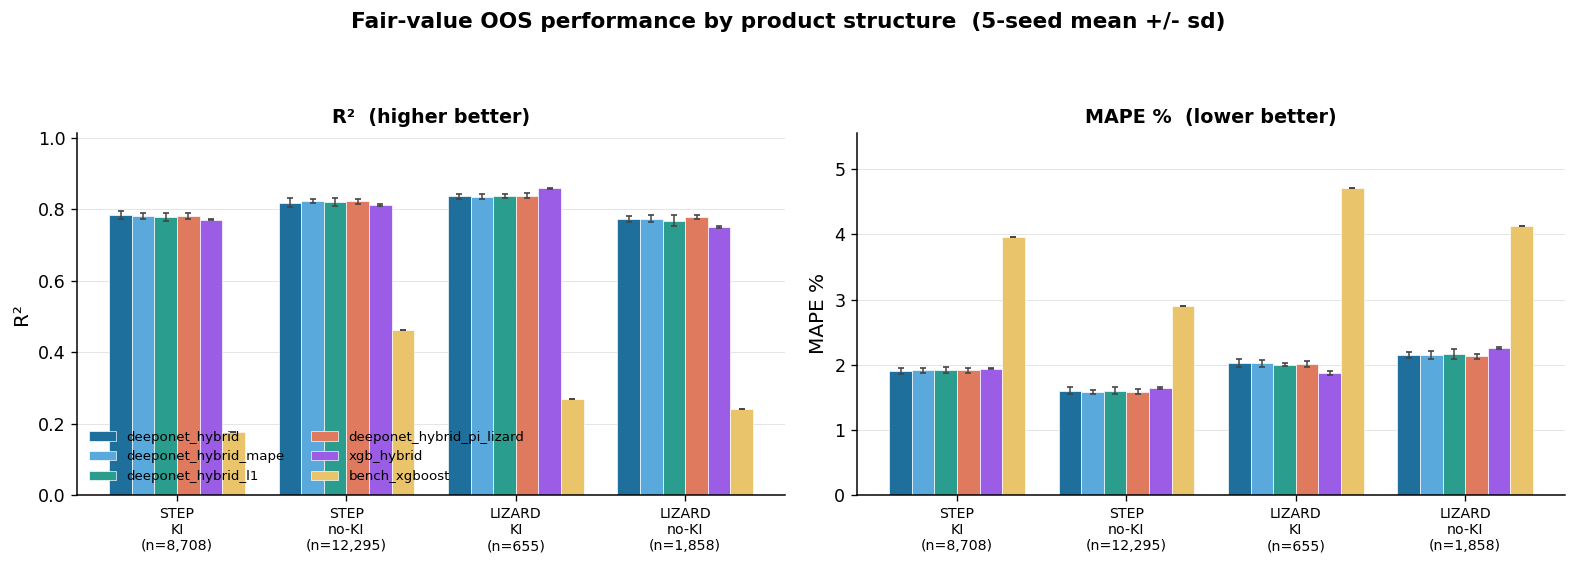

                    model         struct       n     R2  R2_sd   MAPE  MAPE_sd
            bench_xgboost    LIZARD x KI   655.0 0.2693 0.0000 4.7149   0.0000
            bench_xgboost LIZARD x no-KI  1858.0 0.2395 0.0000 4.1253   0.0000
            bench_xgboost      STEP x KI  8708.0 0.1772 0.0000 3.9523   0.0000
            bench_xgboost   STEP x no-KI 12295.0 0.4613 0.0000 2.9073   0.0000
          deeponet_hybrid    LIZARD x KI   655.0 0.8367 0.0066 2.0239   0.0556
          deeponet_hybrid LIZARD x no-KI  1858.0 0.7732 0.0088 2.1421   0.0470
          deeponet_hybrid      STEP x KI  8708.0 0.7835 0.0112 1.9016   0.0451
          deeponet_hybrid   STEP x no-KI 12295.0 0.8189 0.0131 1.5983   0.0549
       deeponet_hybrid_l1    LIZARD x KI   655.0 0.8374 0.0050 2.0012   0.0256
       deeponet_hybrid_l1 LIZARD x no-KI  1858.0 0.7683 0.0157 2.1607   0.0804
       deeponet_hybrid_l1      STEP x KI  8708.0 0.7790 0.0117 1.9221   0.0479
       deeponet_hybrid_l1   STEP x no-KI 12295.0 0.8

In [2]:
# 그림 1: 구조별 R² · MAPE — 모델 그룹바
from sklearn.metrics import r2_score

# 시드별로 계산한 뒤 모델x구조 평균 ± sd (R² 는 비선형이라 pooled 값을 쓰면 안 된다)
rows = []
for name in MODELS:
    d0 = M[M.model == name]
    for s in STRUCTS:
        for seed, g in d0[d0.struct == s].groupby("seed"):
            rows.append(dict(model=name, struct=s, seed=seed, n=len(g),
                             R2=r2_score(g.y_true, g.y_pred),
                             MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
SL = pd.DataFrame(rows)
SL.to_csv(fm.stat("seg_structure_by_seed"), index=False)
S = SL.groupby(["model", "struct"], as_index=False)[["n", "R2", "MAPE", "BiasKRW"]].mean()
S = S.merge(SL.groupby(["model", "struct"], as_index=False)[["R2", "MAPE"]].std()
            .rename(columns={"R2": "R2_sd", "MAPE": "MAPE_sd"}), on=["model", "struct"])
S.to_csv(fm.stat("seg_structure"), index=False)

XL = [s.replace(" x ", "\n") + f"\n(n={int(S[S.struct==s].n.iloc[0]):,})" for s in STRUCTS]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(len(STRUCTS)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = S[S.model == name].set_index("struct").loc[STRUCTS]
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ek = dict(ecolor="#444", lw=0.9, capsize=2)
    ax[0].bar(x + off, v["R2"].values, w, yerr=v["R2_sd"].values, label=name, color=c,
              edgecolor="white", linewidth=0.4, error_kw=ek)
    ax[1].bar(x + off, v["MAPE"].values, w, yerr=v["MAPE_sd"].values, label=name, color=c,
              edgecolor="white", linewidth=0.4, error_kw=ek)
for a, lab, ttl in ((ax[0], "R²", "R²  (higher better)"),
                    (ax[1], "MAPE %", "MAPE %  (lower better)")):
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8.5)
    a.axhline(0, color="#444", lw=0.7); a.set_ylabel(lab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5); a.margins(y=0.18)
ax[0].legend(fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fair-value OOS performance by product structure  (5-seed mean +/- sd)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_metrics"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(S[["model", "struct", "n", "R2", "R2_sd", "MAPE", "MAPE_sd"]].round(4).to_string(index=False))
print("saved ->", fm.image("seg_structure_metrics").name, "|", fm.stat("seg_structure").name)

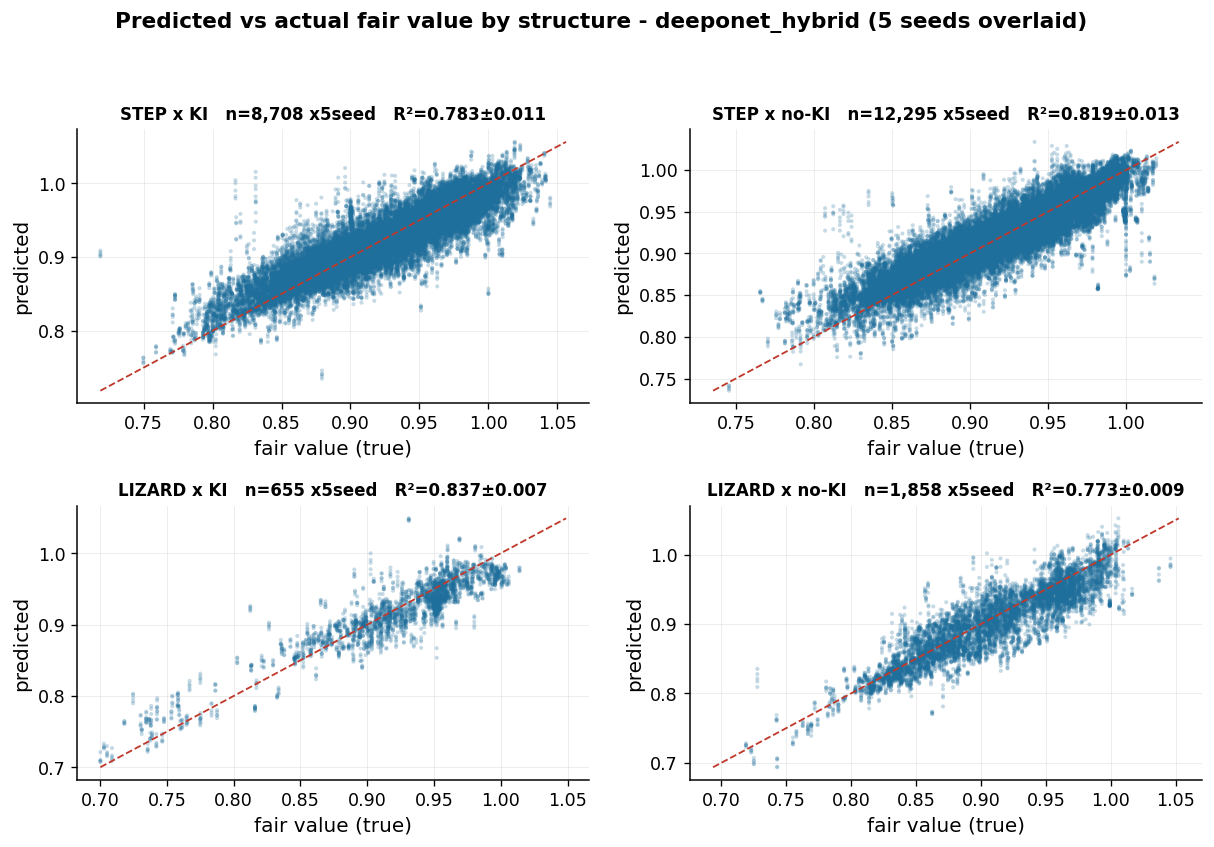

saved -> seg_structure_scatter.png


In [3]:
# 그림 2: 구조별 예측 vs 실제 산점 (대표 모델)
d = M[M.model == BEST]
fig, axs = plt.subplots(2, 2, figsize=(_plot.SLIDE_W * 0.78, 7.2))
for a, s in zip(axs.ravel(), STRUCTS):
    g = d[d.struct == s]
    lim = [min(g.y_true.min(), g.y_pred.min()), max(g.y_true.max(), g.y_pred.max())]
    a.scatter(g.y_true, g.y_pred, s=6, alpha=0.25, color="#1f6f9c", edgecolors="none")
    a.plot(lim, lim, "--", color="#c0392b", lw=1.1)
    a.set_title(f"{s}   n={len(g)//len(SEEDS):,} x{len(SEEDS)}seed   R²={r2s(g)[0]:.3f}±{r2s(g)[1]:.3f}", fontsize=10)
    a.set_xlabel("fair value (true)"); a.set_ylabel("predicted")
    a.grid(color="#dddddd", lw=0.5, alpha=0.6)
for a in axs.ravel()[len(STRUCTS):]:
    a.axis("off")
fig.suptitle(f"Predicted vs actual fair value by structure - {BEST} (5 seeds overlaid)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_structure_scatter"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_structure_scatter").name)

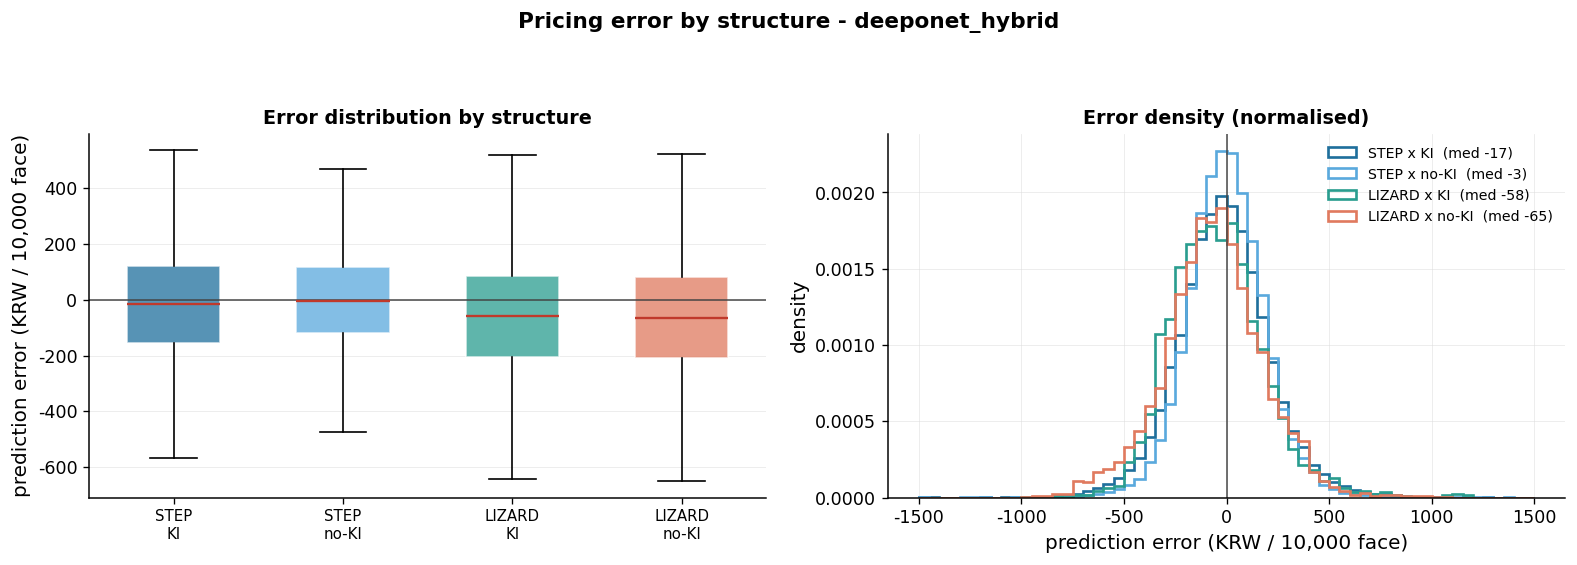

saved -> seg_structure_error.png


In [4]:
# 그림 3: 구조별 오차 분포 (원 단위) — 박스 + 개별 점 일부
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
dat = [d[d.struct == s].err.values * FACE for s in STRUCTS]
bp = ax[0].boxplot(dat, vert=True, patch_artist=True, showfliers=False,
                   medianprops=dict(color="#c0392b", lw=1.4), widths=0.55)
for patch, c in zip(bp["boxes"], _plot._QUAL):
    patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor("white")
ax[0].axhline(0, color="#444", lw=0.9)
ax[0].set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
ax[0].set_ylabel("prediction error (KRW / 10,000 face)")
ax[0].set_title("Error distribution by structure", fontsize=11.5)
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

for j, s in enumerate(STRUCTS):
    e = d[d.struct == s].err.values * FACE
    ax[1].hist(e, bins=60, range=(-1500, 1500), histtype="step", linewidth=1.6,
               color=_plot._QUAL[j], label=f"{s}  (med {np.median(e):+.0f})", density=True)
ax[1].axvline(0, color="#444", lw=0.9)
ax[1].set_xlabel("prediction error (KRW / 10,000 face)"); ax[1].set_ylabel("density")
ax[1].set_title("Error density (normalised)", fontsize=11.5)
ax[1].legend(fontsize=8.5); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Pricing error by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_error"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_structure_error").name)

### 5-1b. 구조 라우팅 물리 앵커 — `deeponet_hybrid_pi_lizard`

물리 제약을 **전 구조에 일괄 적용**한 초기 버전은 5시드 ablation 에서 기각됐다: PI 구조와
`deeponet_hybrid` 의 차이가 노이즈 안이었고(paired t=0.42, p=0.70, 5시드 중 2승), PDE 를 얹으면
STEP 에서 stage-1 이 떨어졌다. 남은 신호는 **LIZARD 에서만 stage-1 이 올랐다**는 것이다.

물리 prior 는 **데이터가 앵커를 못 채우는 곳**에서 값을 한다. STEP 은 표본 8.7k~12.3k 에
stage-1 R² 가 이미 0.96~0.97 로 포화고, LIZARD 는 표본 0.7k~1.9k 에 0.80~0.94 에 그친다.
그래서 물리를 **LIZARD no-KI 에만 라우팅**한다.

- **branch A** (그 외 구조) — `PIStateDeepONet` trunk 61 + state 마스킹 0 → 기능적으로 DeepONet.
  trunk fan_in 61 이라 Kaiming bound 가 작아져 **시드 분산이 준다**(실측 R² sd 0.0118 → 0.0031).
- **branch B** (LIZARD no-KI) — 같은 망 + state 활성 + PDE 잔차, branch A 에서 커리큘럼 초기화.

라우팅 키는 계약 조건만으로 유도한다(`lz_barr_j < 1.15` 중 하나라도 참 AND `B >= 1`) —
parquet 의 `opt_type`·`ki_yn` 과 58,790건 전부 일치하므로 누출이 없다.

아래 대조군 `control_norouting` 은 **같은 branch A 가중치**로 라우팅만 끈 것이라, 시드·초기화·
학습데이터가 동일한 짝지은 대조군이다.


=== 집계 (5시드 평균 ± sd) ===
                   stage1_mean  stage1_sd  final_mean  final_sd  rmse_mean  rmse_sd
model                                                                              
control_norouting      0.94454    0.02224     0.80272   0.00770    0.02145  0.00042
routed                 0.94463    0.02166     0.80398   0.00686    0.02138  0.00037

=== 짝지은 차이 (routed - control_norouting) ===
seed
0    0.00043
1    0.00318
2    0.00006
3    0.00210
4    0.00055
  mean=+0.00126  sd=0.00133  se=0.00059  이긴 시드 5/5


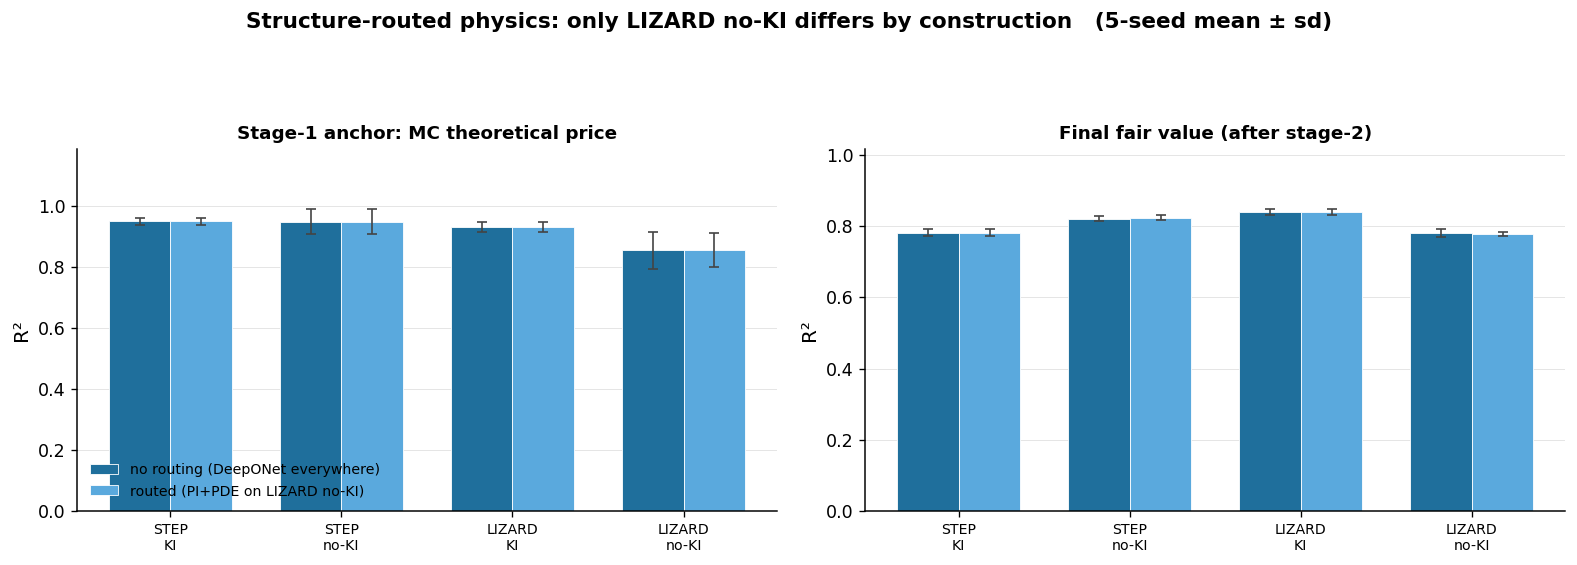


  LIZARD no-KI 행만 branch B 를 쓰므로 그 구조에서만 두 모델이 달라야 한다.
saved -> seg_structure_pi.png


In [5]:
# 라우팅이 목표 구조에서 실제로 값을 하는가 (5시드 평균 ± sd)
rp = fm.stat("exp_pi_route_seeds")
if not rp.exists():
    print("건너뜀 — scratch/run_pi_route_seeds.py 결과 없음")
else:
    RS = pd.read_csv(rp)
    A = RS[RS.scope == "all"]
    print("=== 집계 (5시드 평균 ± sd) ===")
    print(A.groupby("model").agg(
        stage1_mean=("stage1_R2", "mean"), stage1_sd=("stage1_R2", "std"),
        final_mean=("final_R2", "mean"), final_sd=("final_R2", "std"),
        rmse_mean=("final_RMSE", "mean"), rmse_sd=("final_RMSE", "std")).round(5).to_string())

    piv = A.pivot(index="seed", columns="model", values="final_R2")
    dd = piv["routed"] - piv["control_norouting"]
    print("\n=== 짝지은 차이 (routed - control_norouting) ===")
    print(dd.round(5).to_string())
    print(f"  mean={dd.mean():+.5f}  sd={dd.std():.5f}  se={dd.std()/np.sqrt(len(dd)):.5f}  "
          f"이긴 시드 {int((dd>0).sum())}/{len(dd)}")

    ST = RS[RS.scope != "all"]
    order = [s for s in STRUCTS if s in set(ST.scope)]
    fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
    x = np.arange(len(order)); w = .36
    NLAB = {"control_norouting": "no routing (DeepONet everywhere)",
            "routed": "routed (PI+PDE on LIZARD no-KI)"}
    for pi_, col, ttl in [(0, "stage1_R2", "Stage-1 anchor: MC theoretical price"),
                          (1, "final_R2", "Final fair value (after stage-2)")]:
        mu = ST.pivot_table(index="scope", columns="model", values=col, aggfunc="mean").loc[order]
        sg = ST.pivot_table(index="scope", columns="model", values=col, aggfunc="std").loc[order]
        for j, mdl in enumerate(["control_norouting", "routed"]):
            ax[pi_].bar(x + (j - .5) * w, mu[mdl].values, w, yerr=sg[mdl].values, label=NLAB[mdl],
                        color=_plot._QUAL[j], edgecolor="white", linewidth=.5,
                        error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
        ax[pi_].set_xticks(x)
        ax[pi_].set_xticklabels([o.replace(" x ", "\n") for o in order], fontsize=8.5)
        ax[pi_].set_ylabel("R²"); ax[pi_].set_title(ttl, fontsize=11)
        ax[pi_].grid(axis="y", color="#cccccc", lw=.6, alpha=.5); ax[pi_].margins(y=.20)
    ax[0].legend(fontsize=8.5, loc="lower left")
    fig.suptitle("Structure-routed physics: only LIZARD no-KI differs by construction"
                 "   (5-seed mean ± sd)", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    fig.savefig(fm.image("seg_structure_pi"), dpi=400, bbox_inches="tight", transparent=True)
    plt.show()
    print("\n  LIZARD no-KI 행만 branch B 를 쓰므로 그 구조에서만 두 모델이 달라야 한다.")
    print("saved -> seg_structure_pi.png")

## 5-2. 기초자산별 성능

바스켓 **조합**(3개 묶음)과 **개별 지수 포함 여부**를 나눠서 본다. 후자는 한 상품이 3개 지수에
각각 계상되므로 합계가 표본 수를 넘는다 — "그 지수가 들어간 상품의 성능"으로 읽어야 한다.

### 기초자산 지수 약어

3-star 상품은 아래 중 **3개를 worst-of** 로 묶는다 (가장 많이 빠진 자산이 상환·낙인을 결정).

| 티커 | 지수 | 지역 | 비고 |
|---|---|---|---|
| `^KS200` | KOSPI 200 | 한국 | 코스피 시가총액 상위 200종목 |
| `^GSPC` | S&P 500 | 미국 | |
| `^STOXX50E` | EURO STOXX 50 | 유로존 | 표본에서 가장 많이 쓰인 기초자산 |
| `^HSCE` | HSCEI (Hang Seng China Enterprises) | 홍콩·중국 | 홍콩 상장 중국 본토기업(H주). 2015·2021 급락으로 낙인 사태를 일으킨 그 지수 |
| `^HSI` | Hang Seng Index | 홍콩 | HSCEI 와 상관 0.96 로 사실상 같이 움직인다 |
| `^N225` | Nikkei 225 | 일본 | |
| `^NDX` | NASDAQ-100 | 미국 | 소수 |
| `^GDAXI` | DAX | 독일 | 소수 |
| `005930.KS` | 삼성전자 | 한국 | 지수가 아닌 **개별종목** |
| `000660.KS` | SK하이닉스 | 한국 | 개별종목 |

개별종목(삼성전자·SK하이닉스)이 낀 상품은 표본이 작고(각 451·362건) 변동성이 지수보다 훨씬 커서
아래 지수별 판에서 따로 읽어야 한다.

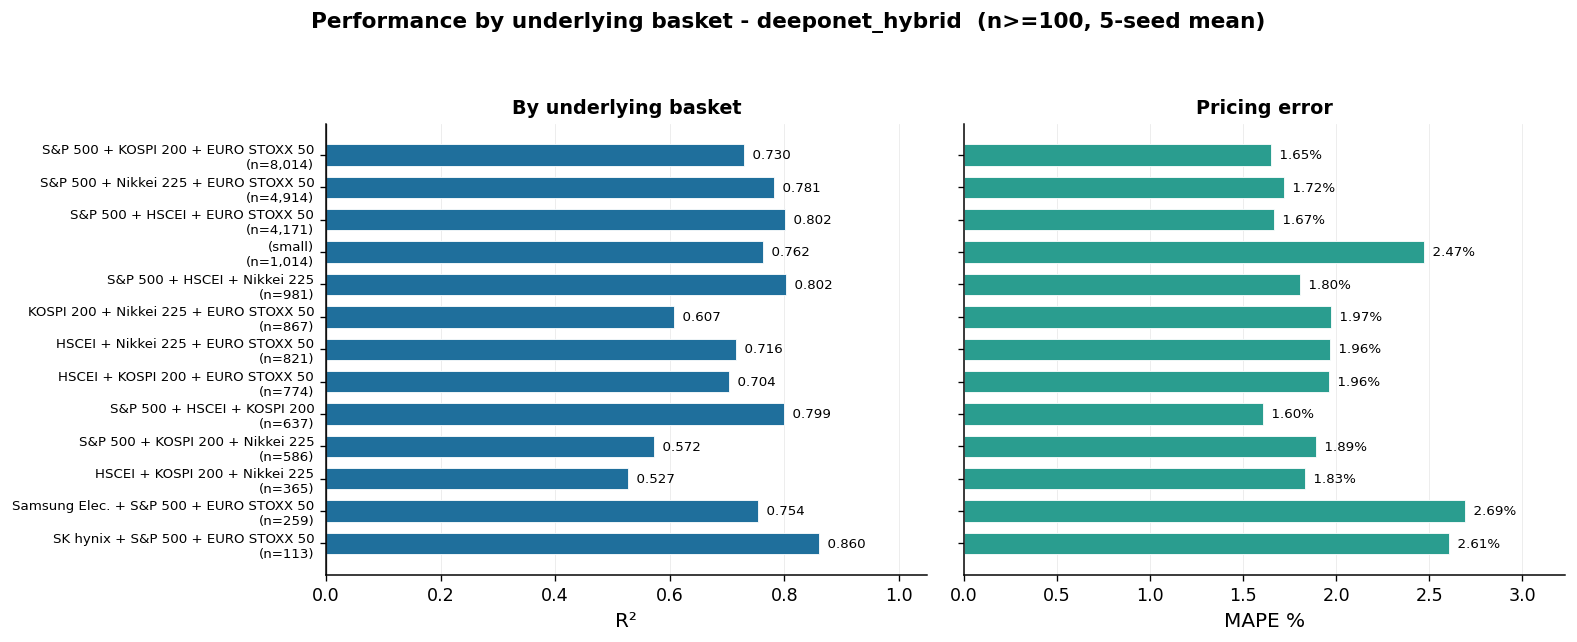

                                n      R2   MAPE%   Bias%
group                                                    
^GSPC|^KS200|^STOXX50E     8014.0  0.7304  1.6508 -0.0606
^GSPC|^N225|^STOXX50E      4914.0  0.7814  1.7159  0.2366
^GSPC|^HSCE|^STOXX50E      4171.0  0.8019  1.6670  0.1098
(small)                    1014.0  0.7620  2.4715 -0.4750
^GSPC|^HSCE|^N225           981.0  0.8024  1.8043  0.0338
^KS200|^N225|^STOXX50E      867.0  0.6072  1.9684 -0.8317
^HSCE|^N225|^STOXX50E       821.0  0.7162  1.9633 -0.9464
^HSCE|^KS200|^STOXX50E      774.0  0.7036  1.9602 -0.8568
^GSPC|^HSCE|^KS200          637.0  0.7994  1.6034 -0.7867
^GSPC|^KS200|^N225          586.0  0.5718  1.8925 -0.8745
^HSCE|^KS200|^N225          365.0  0.5265  1.8310 -0.1774
005930.KS|^GSPC|^STOXX50E   259.0  0.7535  2.6911  1.5495
000660.KS|^GSPC|^STOXX50E   113.0  0.8597  2.6056  1.1398
saved -> seg_underlying_basket.png


In [6]:
# 그림 4: 바스켓 조합별 R² · MAPE (표본 100건 이상)
# 시드별 metrics_by 를 계산한 뒤 평균 ± sd
_rows = []
for name in MODELS:
    for seed in SEEDS:
        dd = M[(M.model == name) & (M.seed == seed)]
        for lab, r in metrics_by(dd.y_true, dd.y_pred, dd.udl_key, min_n=100).iterrows():
            _rows.append({"model": name, "seed": seed, "group": lab, **r.to_dict()})
BUL = pd.DataFrame(_rows)
BUL.to_csv(fm.stat("seg_underlying_basket_by_seed"), index=False)
_num = [c for c in BUL.columns if c not in ("model", "seed", "group")]
BU = {n_: BUL[BUL.model == n_].groupby("group")[_num].mean() for n_ in MODELS}
BUSD = {n_: BUL[BUL.model == n_].groupby("group")[_num].std() for n_ in MODELS}
pd.concat(BU, names=["model", "group"]).to_csv(fm.stat("seg_underlying_basket"))
U = BU[BEST].sort_values("n", ascending=False)
USD = BUSD[BEST].loc[U.index]
lab = [f"{' + '.join(uname(x) for x in i.split('|'))}\n(n={int(v):,})" for i, v in zip(U.index, U["n"])]

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.42 * len(U))))
y = np.arange(len(U))
cols = ["#c0392b" if r < 0 else "#1f6f9c" for r in U["R2"]]
ax[0].barh(y, U["R2"].values, height=0.66, color=cols, edgecolor="white", linewidth=0.5)
ax[0].set_yticks(y); ax[0].set_yticklabels(lab, fontsize=8); ax[0].invert_yaxis()
ax[0].axvline(0, color="#444", lw=0.8)
for i, v in enumerate(U["R2"].values):
    ax[0].text(v, i, f"  {v:.3f}", va="center", fontsize=8)
ax[0].set_xlabel("R²"); ax[0].set_title("By underlying basket", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[0].margins(x=0.22)

ax[1].barh(y, U["MAPE%"].values, height=0.66, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax[1].set_yticks(y); ax[1].set_yticklabels([]); ax[1].invert_yaxis()
for i, v in enumerate(U["MAPE%"].values):
    ax[1].text(v, i, f"  {v:.2f}%", va="center", fontsize=8)
ax[1].set_xlabel("MAPE %"); ax[1].set_title("Pricing error", fontsize=11.5)
ax[1].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[1].margins(x=0.20)

fig.suptitle(f"Performance by underlying basket - {BEST}  (n>=100, 5-seed mean)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_underlying_basket"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(U[["n", "R2", "MAPE%", "Bias%"]].round(4).to_string())
print("saved ->", fm.image("seg_underlying_basket").name)

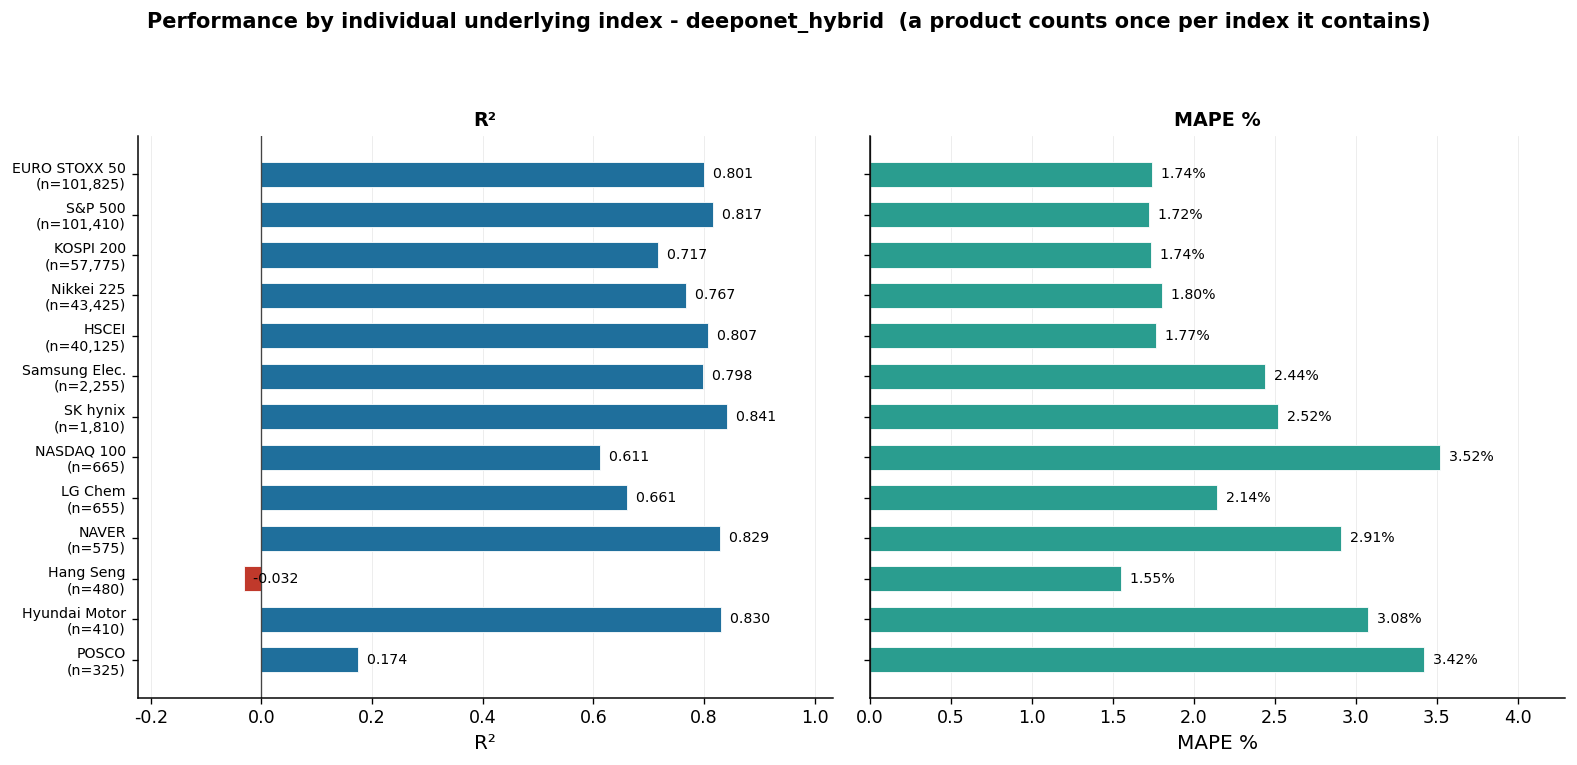

   ticker          name      n      R2   MAPE   BiasKRW
^STOXX50E EURO STOXX 50 101825  0.8006 1.7431   -8.9154
    ^GSPC       S&P 500 101410  0.8168 1.7220   -1.4932
   ^KS200     KOSPI 200  57775  0.7172 1.7358  -29.5754
    ^N225    Nikkei 225  43425  0.7672 1.8039  -15.9868
    ^HSCE         HSCEI  40125  0.8072 1.7650  -23.2297
005930.KS Samsung Elec.   2255  0.7975 2.4394   57.8333
000660.KS      SK hynix   1810  0.8406 2.5206    5.6125
     ^NDX    NASDAQ 100    665  0.6115 3.5196 -266.3832
051910.KS       LG Chem    655  0.6613 2.1423    5.9026
035420.KS         NAVER    575  0.8292 2.9117  -41.1699
     ^HSI     Hang Seng    480 -0.0321 1.5488  -39.0333
005380.KS Hyundai Motor    410  0.8305 3.0782  136.6786
005490.KS         POSCO    325  0.1741 3.4223  291.8320
saved -> seg_underlying_ticker.png


In [7]:
# 그림 5: 개별 지수 포함 여부별 R² · MAPE (한 상품이 3개 지수에 계상됨)
def by_ticker(d0, min_n=200):
    tk = pd.unique(pd.concat([d0.udl1, d0.udl2, d0.udl3]).dropna())
    out = []
    for t in tk:
        g = d0[(d0.udl1 == t) | (d0.udl2 == t) | (d0.udl3 == t)]
        if len(g) < min_n:
            continue
        out.append(dict(ticker=t, name=uname(t), n=len(g), R2=r2s(g)[0],
                        MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
    return pd.DataFrame(out).sort_values("n", ascending=False).reset_index(drop=True)

T = by_ticker(M[M.model == BEST])
pd.concat({name: by_ticker(M[M.model == name]) for name in MODELS},
          names=["model", "i"]).to_csv(fm.stat("seg_underlying_ticker"))

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.5 * len(T))))
y = np.arange(len(T))
YL = [f"{t}\n(n={int(nn):,})" for t, nn in zip(T.name, T.n)]
for a, col, lab, cmapc in ((ax[0], "R2", "R²", None), (ax[1], "MAPE", "MAPE %", "#2a9d8f")):
    v = T[col].values
    c = ["#c0392b" if x < 0 else "#1f6f9c" for x in v] if cmapc is None else cmapc
    a.barh(y, v, height=0.62, color=c, edgecolor="white", linewidth=0.5)
    a.set_yticks(y); a.set_yticklabels(YL if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis(); a.axvline(0, color="#444", lw=0.8)
    fmt = "  {:.3f}" if col == "R2" else "  {:.2f}%"
    for i, x in enumerate(v):
        a.text(x, i, fmt.format(x), va="center", fontsize=8.5)
    a.set_xlabel(lab); a.set_title(lab, fontsize=11.5)
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); a.margins(x=0.22)
fig.suptitle(f"Performance by individual underlying index - {BEST}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_ticker"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(T.round(4).to_string(index=False))
print("saved ->", fm.image("seg_underlying_ticker").name)

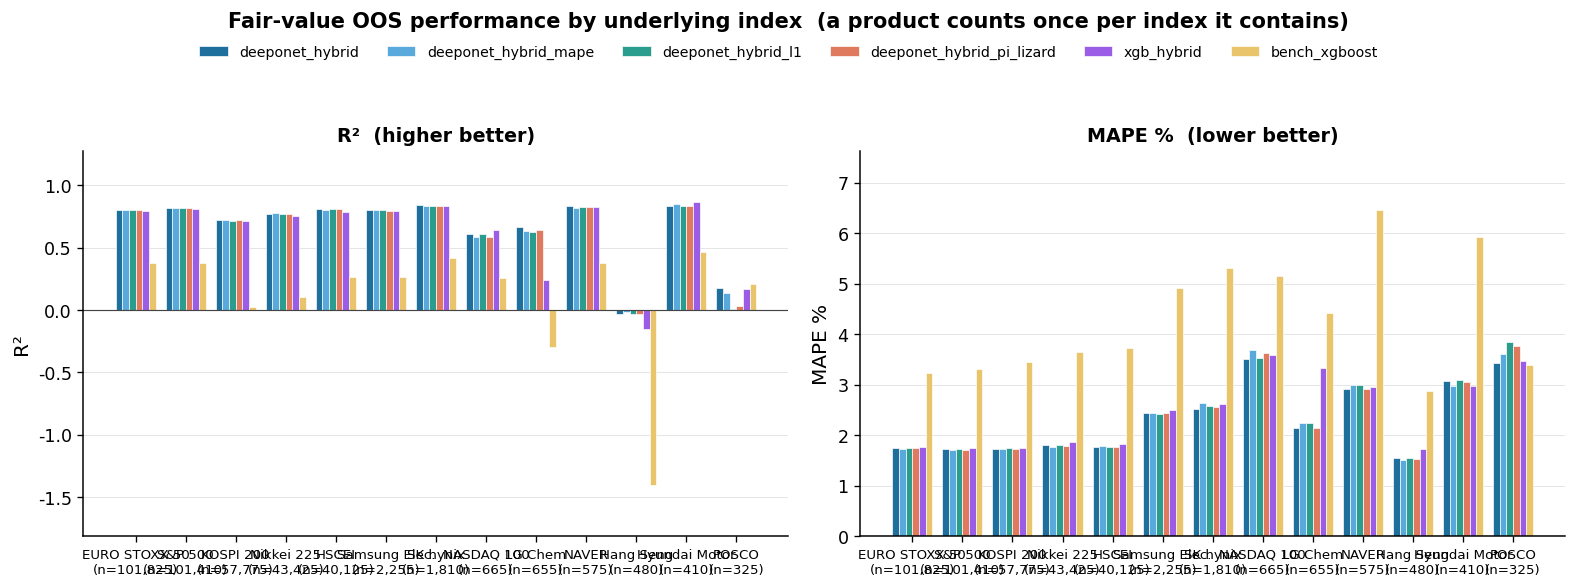

model          bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  deeponet_hybrid_pi_lizard  xgb_hybrid
ticker                                                                                                                        
EURO STOXX 50         0.3754           0.8006              0.7988                0.8031                     0.8018      0.7932
S&P 500               0.3733           0.8168              0.8149                0.8190                     0.8185      0.8088
KOSPI 200             0.0198           0.7172              0.7135                0.7206                     0.7203      0.7093
Nikkei 225            0.1067           0.7672              0.7674                0.7758                     0.7725      0.7554
HSCEI                 0.2624           0.8072              0.8067                0.8000                     0.8060      0.7873
Samsung Elec.         0.2674           0.7975              0.8012                0.7978                     0.7

In [8]:
# 그림 5b: 기초자산 지수별 R² · MAPE — 모델 그룹바 (그림 1 의 구조별 판과 같은 형식)
TK = list(T.ticker)                                     # 그림 5 에서 만든 대표 모델 기준 순서(표본 내림차순)
rows = []
for name in MODELS:
    d0 = M[M.model == name]
    for t in TK:
        g = d0[(d0.udl1 == t) | (d0.udl2 == t) | (d0.udl3 == t)]
        if not len(g):
            continue
        rows.append(dict(model=name, ticker=t, n=len(g), R2=r2s(g)[0],
                         MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
UM = pd.DataFrame(rows)
UM.to_csv(fm.stat("seg_underlying_metrics"), index=False)

XL = [f"{uname(t)}\n(n={int(UM[UM.ticker == t].n.iloc[0]):,})" for t in TK]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(TK)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = UM[UM.model == name].set_index("ticker").reindex(TK)
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ax[0].bar(x + off, v["R2"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
    ax[1].bar(x + off, v["MAPE"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
for a, lab, ttl in ((ax[0], "R²", "R²  (higher better)"),
                    (ax[1], "MAPE %", "MAPE %  (lower better)")):
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8)
    a.axhline(0, color="#444", lw=0.7); a.set_ylabel(lab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5); a.margins(y=0.18)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=len(MODELS), bbox_to_anchor=(0.5, 0.945),
           fontsize=8.5, frameon=False)
fig.suptitle("Fair-value OOS performance by underlying index"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_underlying_metrics"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
_p = UM.pivot(index="ticker", columns="model", values="R2").reindex(TK)
print(_p.rename(index=uname).round(4).to_string())
print("saved ->", fm.image("seg_underlying_metrics").name, "|", fm.stat("seg_underlying_metrics").name)

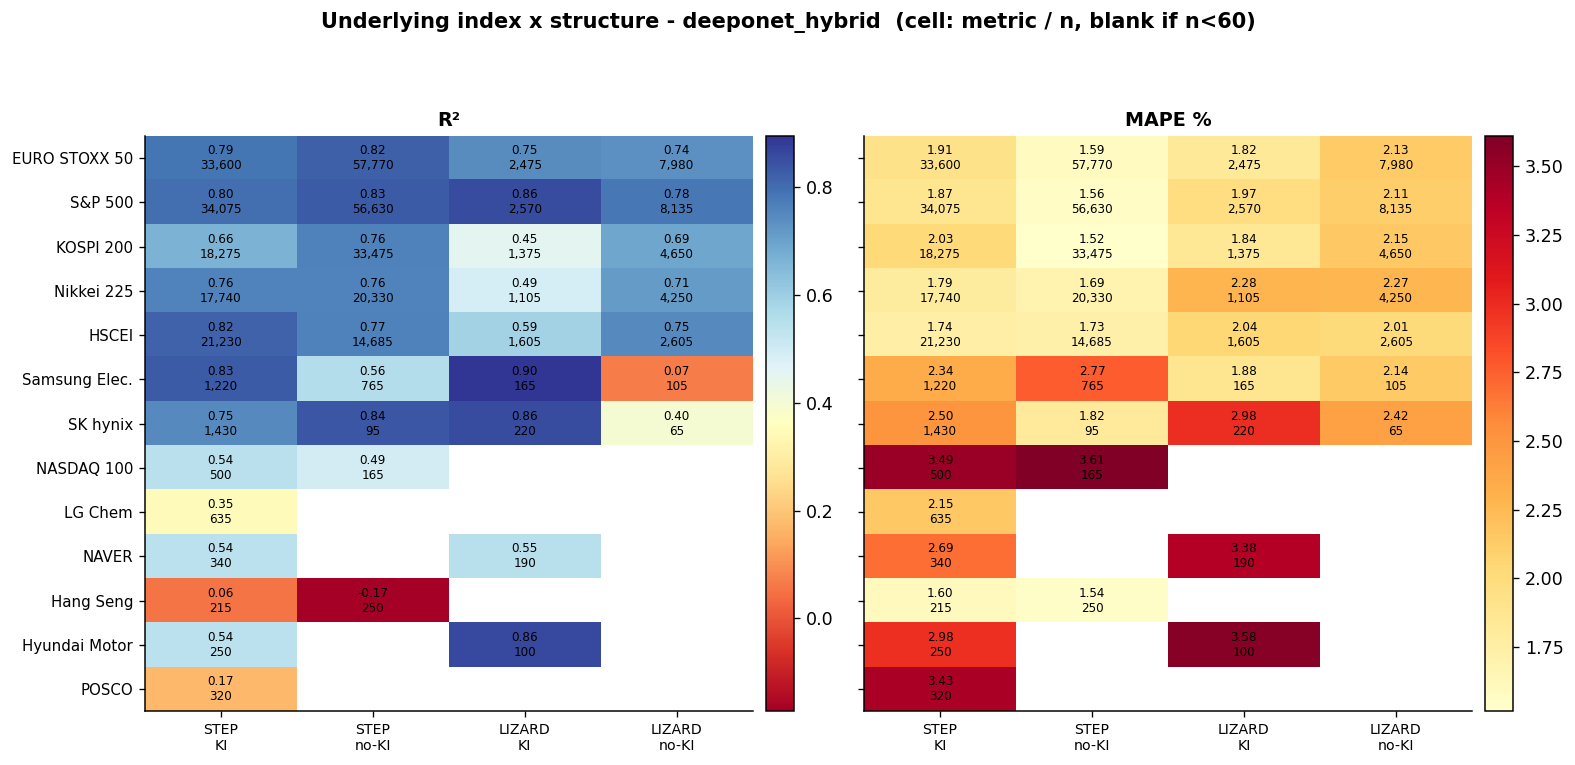

saved -> seg_underlying_x_structure.png


In [9]:
# 그림 6: 지수 × 구조 히트맵 (R² 와 MAPE%)
TK = list(T.ticker)
H_r2 = np.full((len(TK), len(STRUCTS)), np.nan)
H_mp = np.full((len(TK), len(STRUCTS)), np.nan)
H_n = np.zeros((len(TK), len(STRUCTS)), int)
for i, t in enumerate(TK):
    for j, s in enumerate(STRUCTS):
        g = d[(d.struct == s) & ((d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t))]
        H_n[i, j] = len(g)
        if len(g) >= 60:
            H_r2[i, j] = r2s(g)[0]; H_mp[i, j] = g.ape.mean()

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.4, 0.5 * len(TK))))
for a, H, lab, cmap in [(ax[0], H_r2, "R²", "RdYlBu"), (ax[1], H_mp, "MAPE %", "YlOrRd")]:
    im = a.imshow(H, aspect="auto", cmap=cmap)
    a.set_xticks(range(len(STRUCTS)))
    a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=8.5)
    a.set_yticks(range(len(TK)))
    a.set_yticklabels([uname(t) for t in TK] if a is ax[0] else [], fontsize=9)
    for i in range(len(TK)):
        for j in range(len(STRUCTS)):
            if not np.isnan(H[i, j]):
                a.text(j, i, f"{H[i,j]:.2f}\n{H_n[i,j]:,}", ha="center", va="center", fontsize=7.2)
    a.set_title(lab, fontsize=11.5)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
fig.suptitle(f"Underlying index x structure - {BEST}  (cell: metric / n, blank if n<60)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_x_structure"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
assert H_n.sum() > 0, "히트맵 티커 매칭 실패 (T.ticker 와 udl1..3 형식 불일치)"
print("saved ->", fm.image("seg_underlying_x_structure").name)

## 5-3. 시기별 안정성 (walk-forward 폴드 × 구조)

폴드 0 은 train 이 가장 적고(60%) 그 test 구간이 HSCEI 급락 직전이라, 학습에 없던 국면으로
외삽하게 된다. 구조별로도 같은 패턴인지 확인한다.

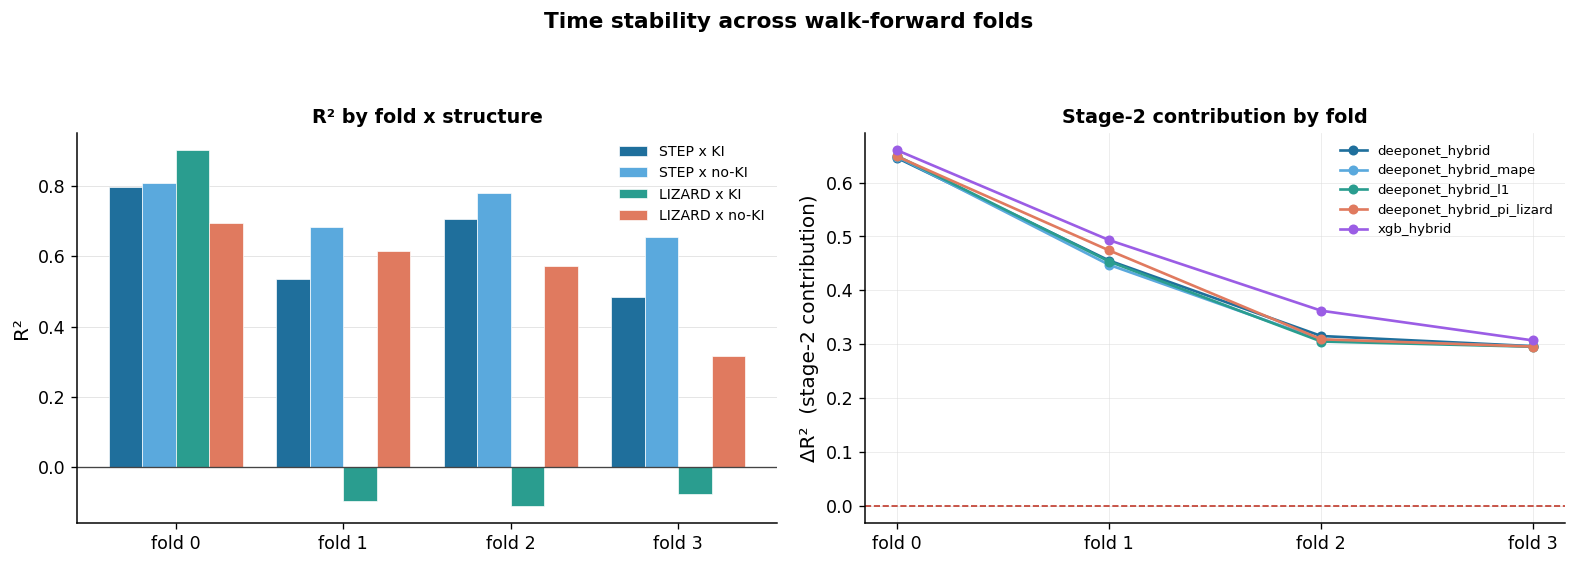

saved -> seg_fold_stability.png


In [10]:
# 그림 7: 폴드 × 구조 R² + stage2 기여
nf = len(D.WF)
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(nf); w = 0.8 / max(len(STRUCTS), 1)
for j, s in enumerate(STRUCTS):
    v, lb = [], []
    for k in range(nf):
        g = d[(d.struct == s) & (d.fold == k)]
        v.append(r2s(g)[0] if len(g) > 30 * len(SEEDS) else np.nan)
        lb.append(len(g))
    ax[0].bar(x + (j - (len(STRUCTS) - 1) / 2) * w, v, w, label=s,
              color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[0].axhline(0, color="#444", lw=0.8); ax[0].set_ylabel("R²")
ax[0].set_title("R² by fold x structure", fontsize=11.5)
ax[0].legend(fontsize=8.5); ax[0].grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)

# stage2 기여 = R2(최종) - R2(MC_hat + margin)
for j, name in enumerate(MODELS):
    dd = M[M.model == name]
    if "resid_pred" not in dd.columns or dd["resid_pred"].isna().all():
        continue
    con = []
    for k in range(nf):
        g = dd[dd.fold == k]
        cv = g.groupby("seed").apply(
            lambda x: r2_score(x.y_true, x.y_pred) - r2_score(x.y_true, x.y_pred - x.resid_pred))
        con.append(float(cv.mean()))
    ax[1].plot(x, con, "o-", lw=1.6, ms=5, color=_plot._QUAL[j % len(_plot._QUAL)], label=name)
ax[1].axhline(0, color="#c0392b", lw=1.0, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[1].set_ylabel("ΔR²  (stage-2 contribution)")
ax[1].set_title("Stage-2 contribution by fold", fontsize=11.5)
ax[1].legend(fontsize=8); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle("Time stability across walk-forward folds", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_fold_stability"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_fold_stability").name)

## 5-4. 단계별(stage) 성능 분해 — 상품 구조별 · 기초자산별

하이브리드는 두 단계다.

```
Fair_hat = MC_hat(stage-1: DeepONet 이 MC 이론가 근사) + recent_margin + Residual_hat(stage-2: 마진 잔차)
```

- **stage-1**: `R²(MC, MC_hat)` — 연산자망이 이론가를 얼마나 재현하나 (이론 파트)
- **stage-2**: `R²(resid, resid_hat)`, `resid = Fair − MC_hat − recent_margin` — 시장 마진을 얼마나 설명하나
- **final**: `R²(Fair, Fair_hat)`

**MAPE 정의**: R² 가 각 단계를 **자기 타깃의 분산**으로 나누듯, MAPE 도 **자기 타깃의 크기**로 나눈다.

```
MAPE_s = mean|pred_s − target_s| / mean|target_s| × 100        (s = stage1 / stage2 / final)
```

per-row 형태 `mean(|오차|/타깃)` 은 잔차가 0 을 넘나들어 stage-2 에서 발산하므로, 세 단계 모두
**집계비**(평균 오차 ÷ 평균 타깃)로 계산한다. stage-1·final 은 타깃이 1 근처에 몰려 있어
per-row 표준 MAPE 와 0.01%p 수준으로 같다(CSV 에 `MAPErow` 로 병기, stage-2 는 NaN).

| 단계 | mean&#124;오차&#124; | mean&#124;타깃&#124; | MAPE |
|---|---|---|---|
| stage-1 (MC 앵커) | 30원 | 9,862원 | **0.31%** |
| stage-2 (마진 잔차) | 201원 | **264원** | **76.1%** |
| final (공정가) | 201원 | 9,230원 | **2.18%** |

**오차(201원)는 stage-2 와 final 이 같다** — `resid = Fair − MC_hat − rm`, `Fair_hat = MC_hat + rm + resid_hat`
이므로 `Fair_hat − Fair ≡ resid_hat − resid` 이기 때문이다. 하지만 **나누는 대상이 다르다**:
final 은 9,230원짜리 공정가를 2.18% 오차로 맞힌 것이고, stage-2 는 264원짜리 마진을 76% 오차로 맞힌 것이다.
**둘 다 사실이고, 후자가 이 모델의 진짜 난이도다.** 세 값의 범위가 0.2%~96% 로 넓어 MAPE 패널은 **로그축**을 쓴다.

> **R² 패널과 교차검증**: `R² = 1 − (RMSE/σ)²` 이므로 `√(1−R²) = RMSE/σ`. MAPE(평균절대)와는 다른 통계량인데
> stage-2 에서 두 값이 1%p 이내로 붙는다 (STEP×KI 81.5% vs 82.5%). 즉 **왼쪽 R² 패널과 오른쪽 MAPE 패널은
> 같은 사실을 다른 단위로 말한다** — "잔차 분산의 32% 설명" = "상대오차 82% 남음". 아래 셀이 매 실행마다 검증한다.

분모를 공정가로 통일한 값도 CSV 에 `MAPEfair` 로 함께 저장한다(항등식 때문에 stage-2 = final).

> **R² 읽을 때 주의**: `R² = 1 − MSE/Var(target)` 이라 **타깃 분산이 다른 세그먼트끼리 R² 를 직접 비교하면 오해**한다.
> LIZARD×KI 와 STEP×KI 는 RMSE 가 288 vs 290원으로 사실상 같은데 R² 는 0.76 vs 0.66 이다 —
> 차이는 공정가 표준편차(592 vs 498원)뿐이다. 아래 세 번째 패널이 그 관계를 직접 보인다.

**stage-2 오차 = final 오차 (항등식)**: `resid = Fair − MC_hat − rm` 이고 `Fair_hat = MC_hat + rm + resid_hat`
이므로 `Fair_hat − Fair ≡ resid_hat − resid` 다. 두 단계의 **오차는 같은 값**이고, R² 만 분모가 다르다
(stage-2 는 `Var(resid)`, final 은 `Var(Fair)`).

그래서 MAPE 패널도 R² 패널과 **똑같이 3막대**로 그리되, **stage-2 막대와 final 막대는 항등식에 의해 높이가 같다**.
이건 오류가 아니라 결과다 — **공정가 오차는 전부 stage-2 에서 나온다**는 뜻이고, stage-1(이론가 재현)의
기여분은 그 왼쪽 막대가 얼마나 낮은지로 읽는다. stage-2 가 잔차 분산을 얼마나 설명했는지는 R² 패널에서 본다.

In [11]:
# 단계별 지표 (구조별 · 기초자산별) — R², MAPE(공정가 분모), 표준 MAPE, RMSE(원)
from sklearn.metrics import r2_score

HYB = [m for m in MODELS if "mc_pred" in P[(m, SEEDS[0])].columns]   # 2단계 모델만 (직접 벤치마크 제외)
STAGES = [("stage1", "mc_true", "mc_pred", "MC anchor"),
          ("stage2", "resid_true", "resid_pred", "margin residual"),
          ("final", "y_true", "y_pred", "fair value")]
STAGES_TP = [(s_[0], s_[1], s_[2]) for s_ in STAGES]     # (단계, 참값열, 예측열) — ablation 셀 재사용


def _stage_metrics(sub):
    """세 단계 지표.
     MAPE     = mean|오차| / mean|자기 타깃| — R² 와 같은 규칙(각 단계를 자기 타깃 크기로 정규화).
                per-row 형태는 잔차가 0 을 넘나들어 stage-2 에서 발산하므로 집계비를 쓴다.
     MAPErow  = mean(|오차| / 자기 타깃) — per-row 표준형. stage-2 는 발산하므로 NaN.
     MAPEfair = mean(|오차| / 공정가) — 분모를 공정가로 통일(항등식 때문에 stage2 = final)."""
    fair = sub["y_true"].abs().values
    row = {}
    for sname, tc, pc, _ in STAGES:
        e = np.abs((sub[pc] - sub[tc]).values)
        tgt = sub[tc].abs().values
        _v = sub.groupby("seed").apply(lambda x: r2_score(x[tc], x[pc]))   # R² 는 시드별
        row[f"{sname}_R2"] = float(_v.mean())
        row[f"{sname}_R2_sd"] = float(_v.std())
        row[f"{sname}_MAPE"] = float(e.mean() / tgt.mean() * 100)               # 자기 타깃 분모(집계비)
        row[f"{sname}_MAPErow"] = (np.nan if sname == "stage2"
                                   else float((e / tgt).mean() * 100))          # per-row 표준형
        row[f"{sname}_MAPEfair"] = float((e / fair).mean() * 100)               # 공통 분모 = 공정가
        row[f"{sname}_MTGT"] = float(tgt.mean() * FACE)                         # mean|타깃| (원)
        row[f"{sname}_RMSE"] = float(np.sqrt((e ** 2).mean()) * FACE)
        row[f"{sname}_SD"] = float(sub[tc].std() * FACE)
    return row


def stage_table(d, group_col, min_n=30):
    out = []
    for g, sub in d.groupby(group_col):
        if len(sub) < min_n:
            continue
        out.append({"group": g, "n": len(sub), **_stage_metrics(sub)})
    return pd.DataFrame(out).set_index("group")


def stage_table_ticker(d, min_n=200):
    tk = pd.unique(pd.concat([d.udl1, d.udl2, d.udl3]).dropna())
    out = []
    for t in tk:
        sub = d[(d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t)]
        if len(sub) < min_n:
            continue
        out.append({"group": uname(t), "n": len(sub), **_stage_metrics(sub)})
    return pd.DataFrame(out).sort_values("n", ascending=False).set_index("group")


ST = {m: stage_table(M[M.model == m], "struct") for m in HYB}
UT = {m: stage_table_ticker(M[M.model == m]) for m in HYB}
pd.concat(ST, names=["model", "group"]).to_csv(fm.stat("seg_stage_structure"))
pd.concat(UT, names=["model", "group"]).to_csv(fm.stat("seg_stage_underlying"))

SHOW = ["n", "stage1_R2", "stage2_R2", "final_R2",
        "stage1_MAPE", "stage2_MAPE", "final_MAPE", "final_MAPErow"]
print(f"=== 상품 구조별 단계 지표 — {STAGE_MODEL}  (MAPE 분모 = 각 단계 자기 타깃) ===")
print(ST[STAGE_MODEL].reindex(STRUCTS)[SHOW].round(4).to_string())
print(f"\n=== 기초자산 지수별 단계 지표 — {STAGE_MODEL} ===")
print(UT[STAGE_MODEL][SHOW].round(4).to_string())
# ── stage-2 MAPE 검증 ────────────────────────────────────────────────────
_m = M[M.model == STAGE_MODEL]
_e2 = (_m.resid_pred - _m.resid_true).values          # stage-2 오차
_ef = (_m.y_pred - _m.y_true).values                  # final 오차
_gap = float(np.abs(_e2 - _ef).max() * FACE)
assert _gap < 0.01, f"항등식 위반: e_stage2 != e_final (최대 {_gap:.4g}원)"
print(f"\n[검증①] 항등식  e_stage2 = e_final : 최대 절대차 {_gap:.2e}원 (float32 반올림)")

_d = ST[STAGE_MODEL]
print(f"[검증②] MAPE 비 = 분모 비 (오차는 같고 분모만 다르다):")
print(("   " + (_d["stage2_MAPE"] / _d["final_MAPE"]).round(2).astype(str)
       + "  vs  " + (_d["final_MTGT"] / _d["stage2_MTGT"]).round(2).astype(str)).to_string())

# R² 교차검증: √(1−R²) = RMSE/σ. MAPE(평균절대) 와 다른 통계량인데 값이 붙어야 정상.
_x = pd.DataFrame({"MAPE_stage2": _d["stage2_MAPE"],
                   "sqrt(1-R2)": np.sqrt(np.clip(1 - _d["stage2_R2"], 0, None)) * 100})
_x["diff%p"] = (_x["MAPE_stage2"] - _x["sqrt(1-R2)"]).abs()
print(f"[검증③] R² 패널과 교차검증 (최대 차이 {_x['diff%p'].max():.2f}%p)")
print(_x.round(2).to_string())

_r = _m.resid_true.abs().values * FACE
_per = np.abs(_e2) / _m.resid_true.abs().values * 100
print(f"[검증④] per-row 표준 MAPE 가 stage-2 에서 못 쓰이는 이유 — "
      f"|resid|<1원 {int((_r < 1).sum())}건, per-row 평균 {_per.mean():,.0f}% (발산) / "
      f"중앙값 {np.median(_per):.0f}% ≈ 집계비")

print("\n집계비 MAPE vs per-row 표준 MAPE (stage-1·final): 최대 차이 "
      f"{max(abs(_d['stage1_MAPE']-_d['stage1_MAPErow']).max(), abs(_d['final_MAPE']-_d['final_MAPErow']).max()):.4f}%p")
print("saved ->", fm.stat("seg_stage_structure").name, "|", fm.stat("seg_stage_underlying").name)

=== 상품 구조별 단계 지표 — deeponet_hybrid_mape  (MAPE 분모 = 각 단계 자기 타깃) ===
                    n  stage1_R2  stage2_R2  final_R2  stage1_MAPE  stage2_MAPE  final_MAPE  final_MAPErow
group                                                                                                     
STEP x KI       43540     0.9555     0.5522    0.7823       0.4114      66.5957      1.9024         1.9116
STEP x no-KI    61475     0.9593     0.6858    0.8235       0.2810      54.8912      1.5681         1.5811
LIZARD x KI      3275     0.9313     0.3674    0.8351       0.6870      80.1556      1.9998         2.0199
LIZARD x no-KI   9290     0.7827     0.4782    0.7733       0.6230      73.2812      2.1497         2.1434

=== 기초자산 지수별 단계 지표 — deeponet_hybrid_mape ===
                    n  stage1_R2  stage2_R2  final_R2  stage1_MAPE  stage2_MAPE  final_MAPE  final_MAPErow
group                                                                                                     
EURO STOXX 50  101825     0.9

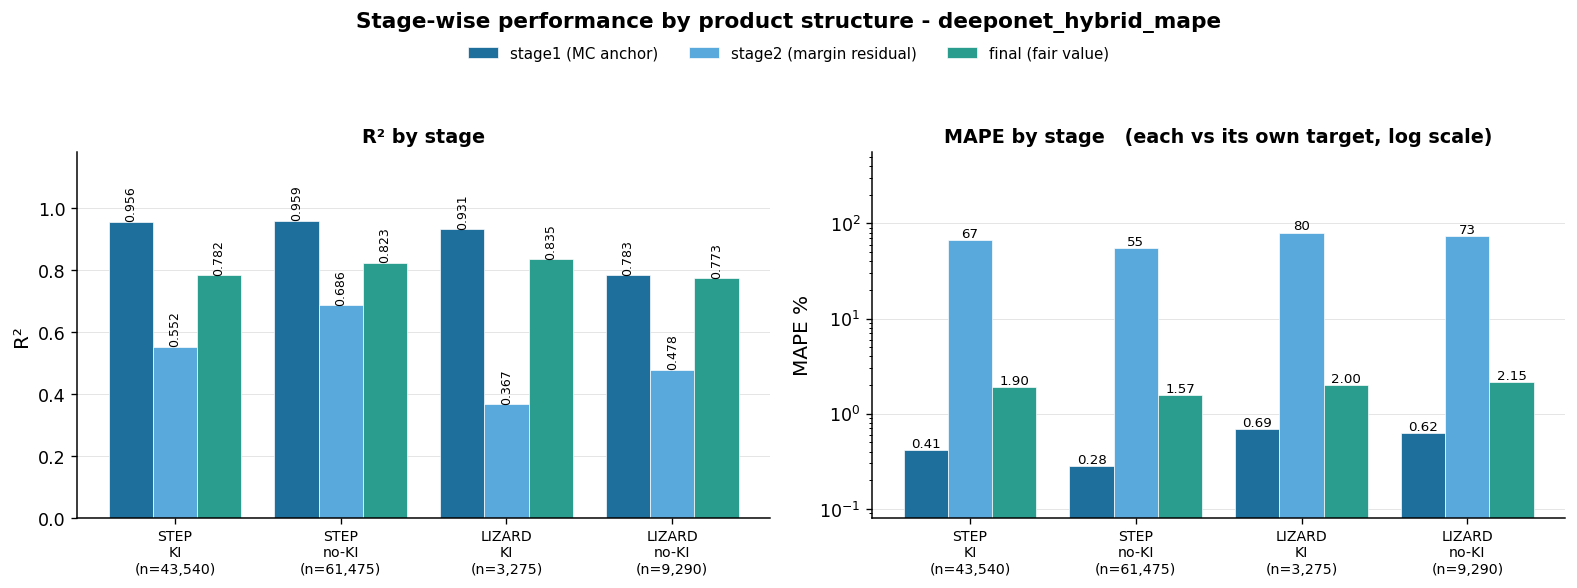

saved -> seg_stage_structure.png


In [12]:
# 그림 8: 상품 구조별 단계 지표 — R² · MAPE
S3 = ST[STAGE_MODEL].reindex(STRUCTS)
XL = [s.replace(" x ", "\n") + f"\n(n={int(v):,})" for s, v in zip(STRUCTS, S3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(STRUCTS))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = S3[f"{sname}_R2"].values
    b = ax[0].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[0].text(r.get_x() + r.get_width() / 2, val, f"{val:.3f}", ha="center",
                   va="bottom" if val >= 0 else "top", fontsize=7.5, rotation=90)
ax[0].set_ylabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].set_ylim(0, 1.18)

for j, (sname, _t, _p, lab) in enumerate(STAGES):        # MAPE 도 R² 와 같은 규칙: 자기 타깃 분모
    v = S3[f"{sname}_MAPE"].values
    b = ax[1].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[1].text(r.get_x() + r.get_width() / 2, val,
                   f"{val:.2f}" if val < 10 else f"{val:.0f}", ha="center", va="bottom", fontsize=8)
_v = np.concatenate([S3[f"{s_[0]}_MAPE"].values for s_ in STAGES])
ax[1].set_yscale("log"); ax[1].set_ylim(max(0.05, _v.min() / 3.5), _v.max() * 7)
ax[1].set_ylabel("MAPE %")
ax[1].set_title("MAPE by stage   (each vs its own target, log scale)", fontsize=11.5)

for a in ax:
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax[0].axhline(0, color="#444", lw=0.7)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by product structure - {STAGE_MODEL}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_structure"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_structure").name)

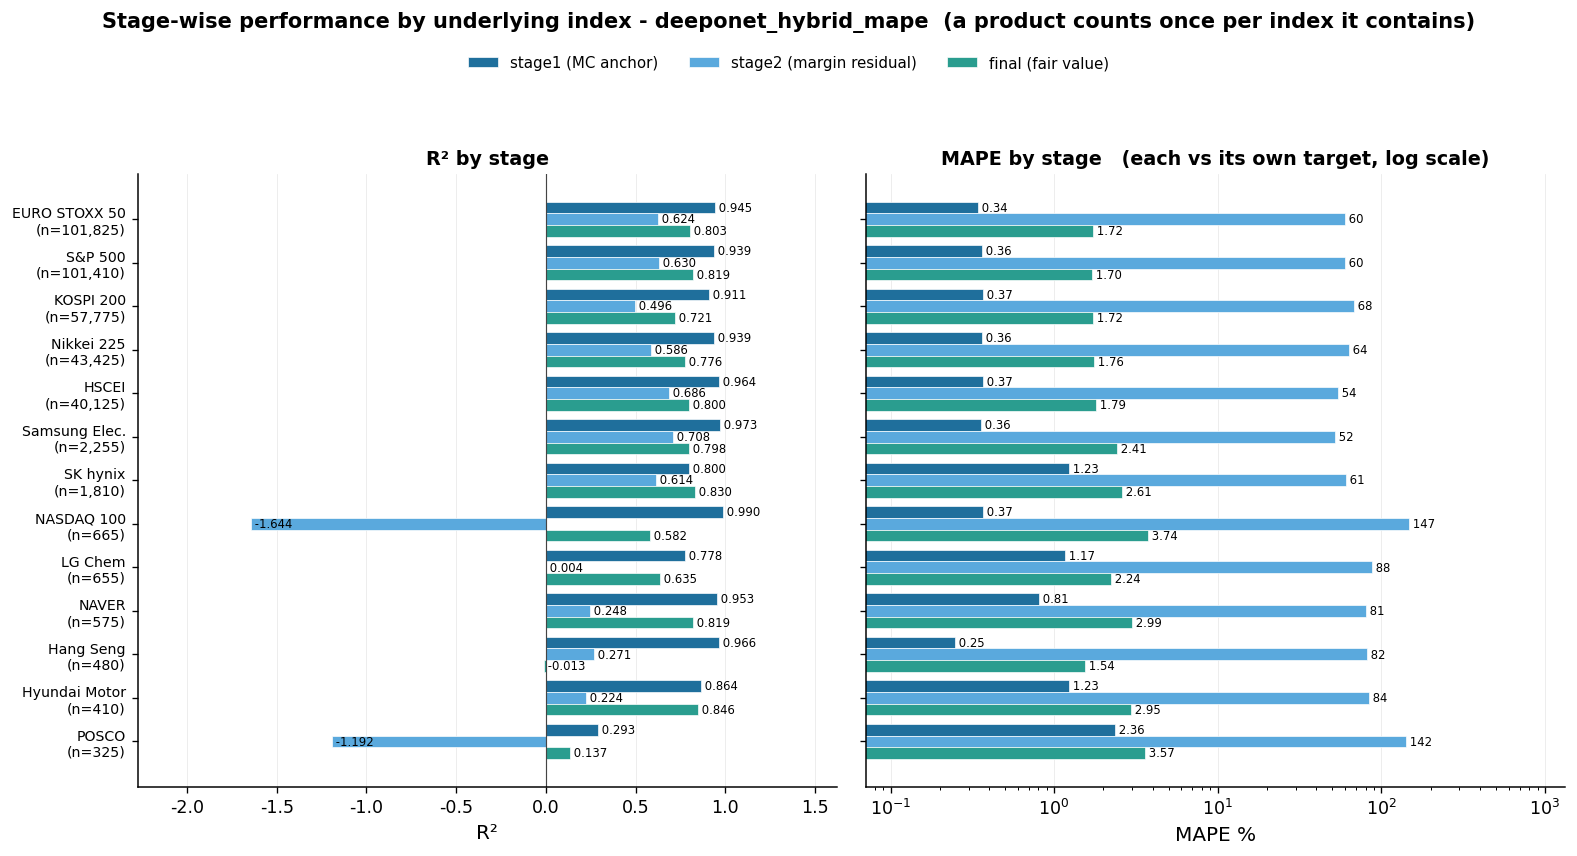

saved -> seg_stage_underlying.png


In [13]:
# 그림 9: 기초자산 지수별 단계 지표 — R² · MAPE
U3 = UT[STAGE_MODEL]
YL = [f"{i}\n(n={int(v):,})" for i, v in zip(U3.index, U3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(5.0, 0.56 * len(U3))))
y = np.arange(len(U3))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = U3[f"{sname}_R2"].values
    ax[0].barh(y + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
               color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for k, val in enumerate(v):
        ax[0].text(val, y[k] + (j - (len(STAGES) - 1) / 2) * w1, f" {val:.3f}",
                   va="center", fontsize=7)
ax[0].set_xlabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].margins(x=0.24)

for j, (sname, _t, _p, lab) in enumerate(STAGES):        # MAPE 도 R² 와 같은 규칙: 자기 타깃 분모
    v = U3[f"{sname}_MAPE"].values
    ax[1].barh(y + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
               color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for k, val in enumerate(v):
        ax[1].text(val, y[k] + (j - (len(STAGES) - 1) / 2) * w1,
                   f" {val:.2f}" if val < 10 else f" {val:.0f}", va="center", fontsize=7)
_v = np.concatenate([U3[f"{s_[0]}_MAPE"].values for s_ in STAGES])
ax[1].set_xscale("log"); ax[1].set_xlim(max(0.05, _v.min() / 3.5), _v.max() * 9)
ax[1].set_xlabel("MAPE %")
ax[1].set_title("MAPE by stage   (each vs its own target, log scale)", fontsize=11.5)

for a in ax:
    a.set_yticks(y); a.set_yticklabels(YL if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis()
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
ax[0].axvline(0, color="#444", lw=0.7)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by underlying index - {STAGE_MODEL}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_underlying"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_underlying").name)

C:\Users\Juhwankim\AppData\Local\Temp\ipykernel_10584\4225084985.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=(0, 0, 1, 0.90))


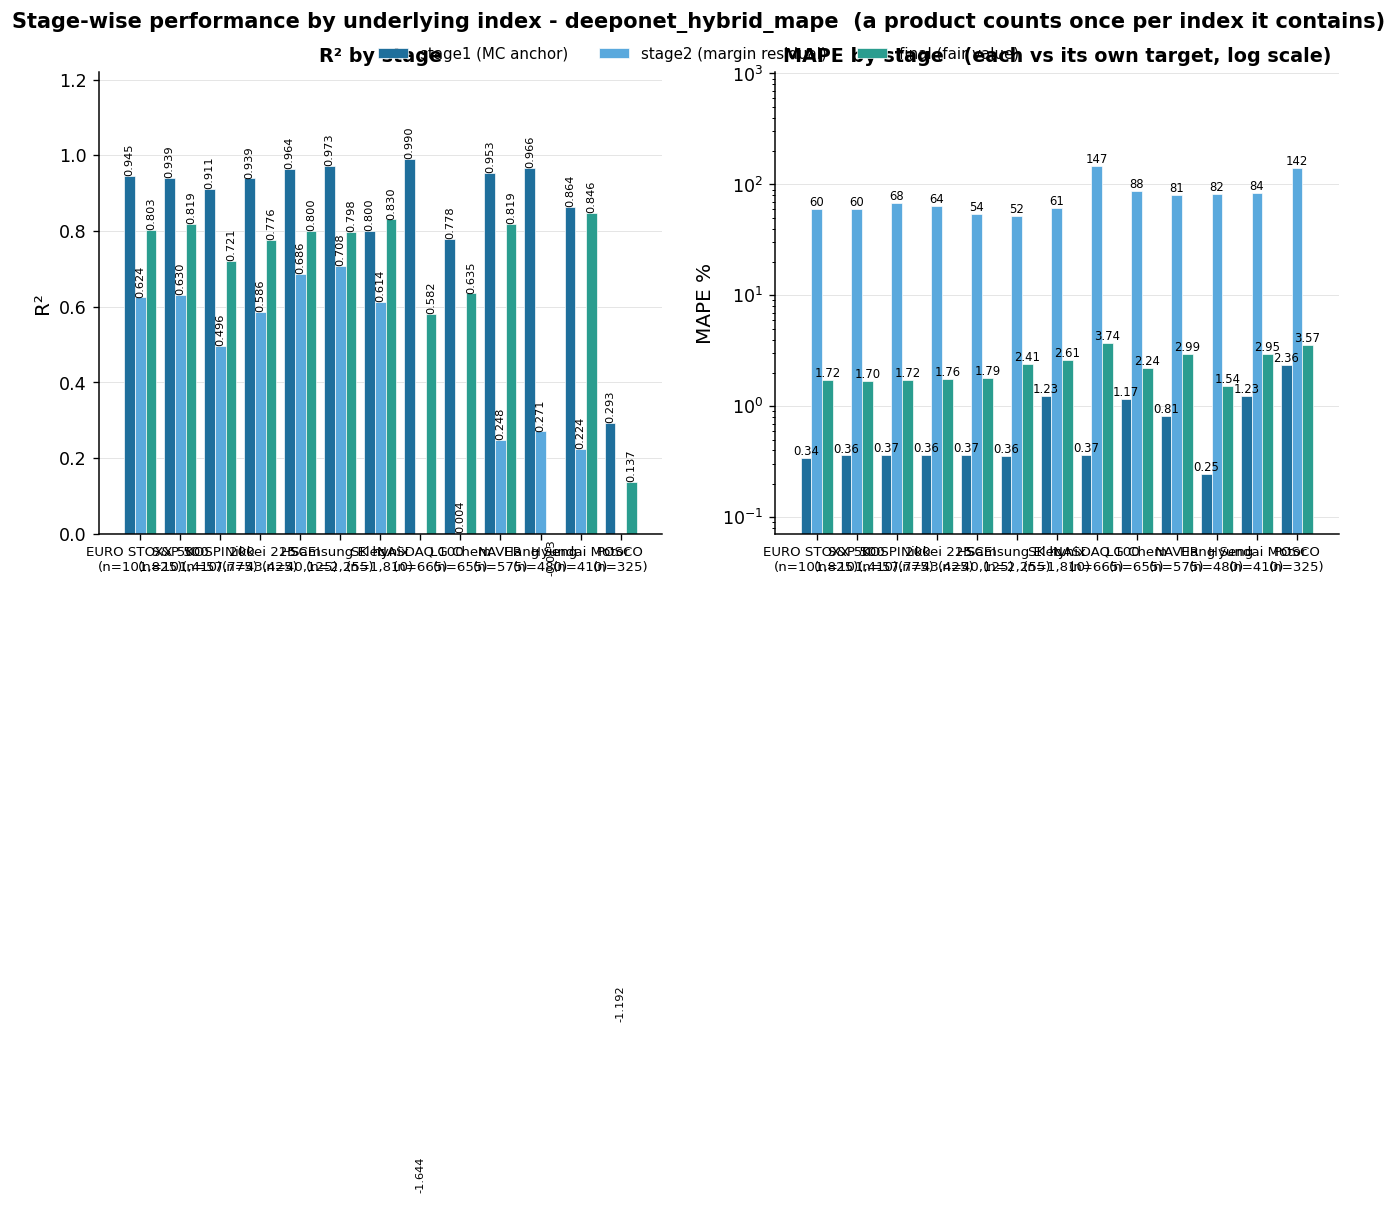

saved -> seg_stage_underlying_vertical.png


In [14]:
# 그림 9b: 기초자산 지수별 단계 지표 — 세로 막대 버전 (그림 9 의 가로판과 같은 수치)
U3 = UT[STAGE_MODEL]
XL = [f"{i}\n(n={int(v):,})" for i, v in zip(U3.index, U3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(U3))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = U3[f"{sname}_R2"].values
    b = ax[0].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[0].text(r.get_x() + r.get_width() / 2, val, f"{val:.3f}", ha="center",
                   va="bottom" if val >= 0 else "top", fontsize=6.8, rotation=90)
ax[0].set_ylabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].set_ylim(0, 1.22)

for j, (sname, _t, _p, lab) in enumerate(STAGES):        # MAPE 도 R² 와 같은 규칙: 자기 타깃 분모
    v = U3[f"{sname}_MAPE"].values
    b = ax[1].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[1].text(r.get_x() + r.get_width() / 2, val,
                   f"{val:.2f}" if val < 10 else f"{val:.0f}", ha="center", va="bottom", fontsize=7)
_v = np.concatenate([U3[f"{s_[0]}_MAPE"].values for s_ in STAGES])
ax[1].set_yscale("log"); ax[1].set_ylim(max(0.05, _v.min() / 3.5), _v.max() * 7)
ax[1].set_ylabel("MAPE %")
ax[1].set_title("MAPE by stage   (each vs its own target, log scale)", fontsize=11.5)

for a in ax:
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax[0].axhline(0, color="#444", lw=0.7)

h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by underlying index - {STAGE_MODEL}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_underlying_vertical"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_underlying_vertical").name)

## 5-5. R² 해부 — 리자드가 R² 가 높은 건 오차가 작아서가 아니라 분산이 커서

`R² = 1 − SS_res/SS_tot = 1 − (RMSE/σ_y)²` 다. **분자(오차)와 분모(타깃 분산)를 분리**해서 보면
LIZARD×KI 의 높은 R²(0.763)가 어디서 오는지 드러난다.

- LIZARD×KI 와 STEP×KI 의 **RMSE 는 288 vs 290원으로 사실상 같다**(분자 동일).
- 그런데 공정가 표준편차는 **592 vs 498원**(분모가 19% 넓다).
- 그래서 R² 만 0.763 vs 0.661 로 벌어진다. MAPE 로 보면 오히려 2.42% vs 2.35% 로 리자드가 나쁘다.

④ 패널의 **반사실(counterfactual)** 이 결정적이다 — 각 구조의 오차를 그대로 두고 분모만
전체 OOS 공통 분산으로 바꿔 평가하면 순위가 뒤집힌다. 세그먼트 비교는 R² 가 아니라
**MAPE·RMSE 로 해야 한다**는 뜻이다.

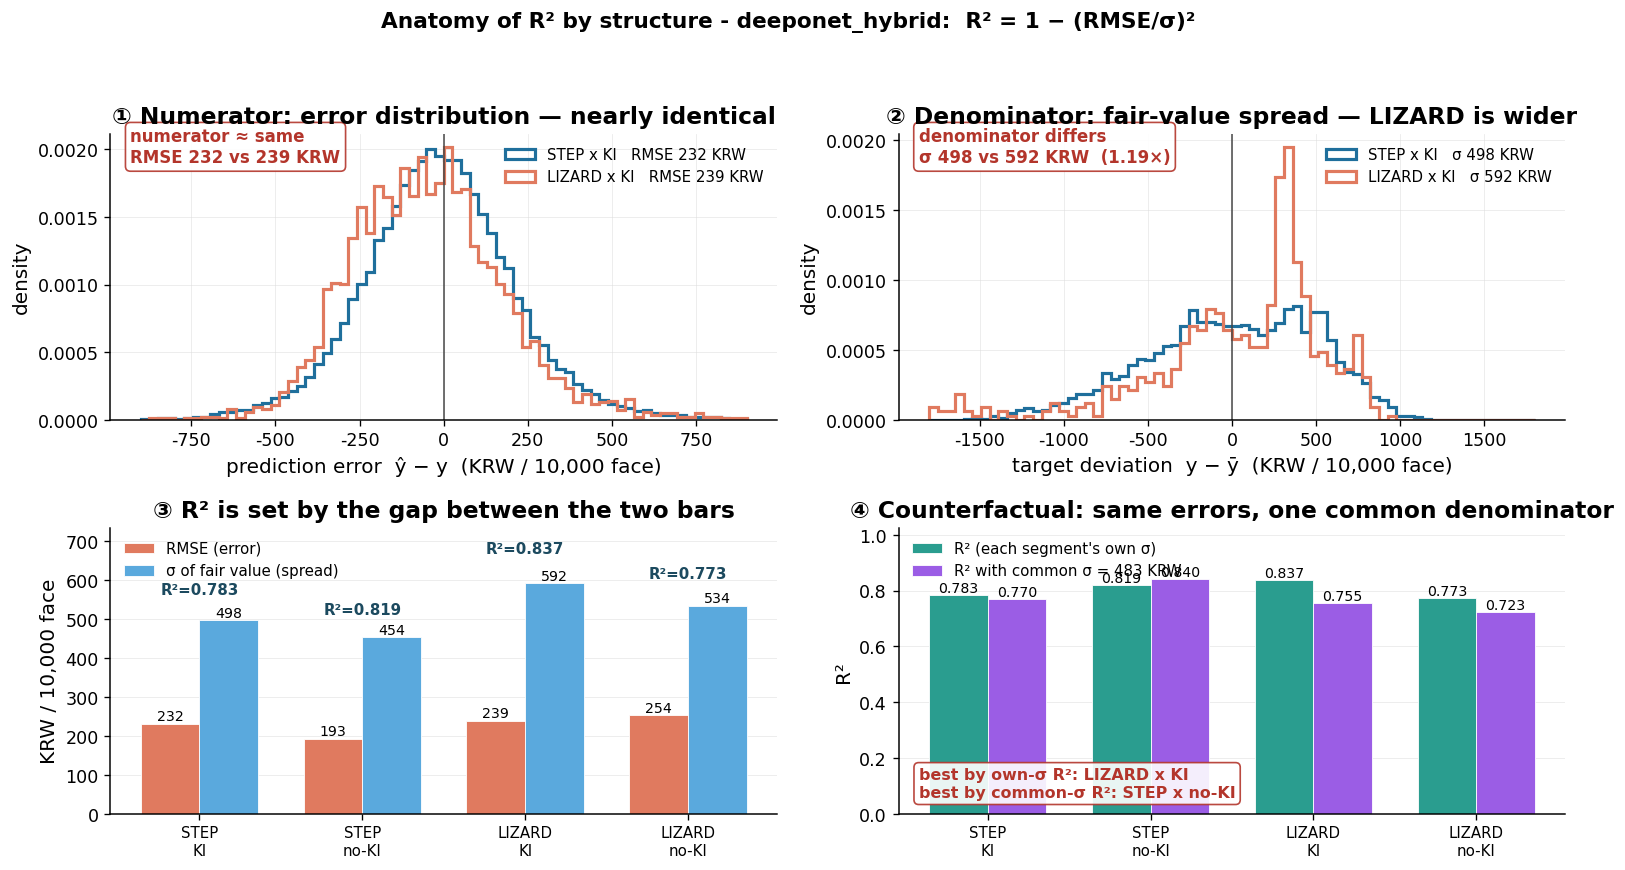

struct                n    RMSE       σ  RMSE/σ      R²    R²(공통σ)   MAPE%
STEP x KI        43,540   231.5   497.6   0.465  +0.783     +0.770   1.902
STEP x no-KI     61,475   193.0   453.6   0.426  +0.819     +0.840   1.598
LIZARD x KI       3,275   239.1   591.8   0.404  +0.837     +0.755   2.024
LIZARD x no-KI    9,290   254.3   534.0   0.476  +0.773     +0.723   2.142

공통 σ (전체 OOS) = 483.0 KRW
saved -> seg_r2_variance_anatomy.png


In [15]:
# 그림 10: R² 해부 (2×2) — 분자(오차)는 같고 분모(분산)가 다르다
d = M[M.model == BEST]
PAIR = ["STEP x KI", "LIZARD x KI"]          # RMSE 가 거의 같은 쌍 (대비가 가장 선명)
COL = {"STEP x KI": "#1f6f9c", "LIZARD x KI": "#e07a5f"}
RD, GY = "#b3352b", "#777777"

st = {}
for s in STRUCTS:
    g = d[d.struct == s]
    e = (g.y_pred - g.y_true).values * FACE
    dev = (g.y_true - g.y_true.mean()).values * FACE
    st[s] = dict(n=len(g), err=e, dev=dev, rmse=float(np.sqrt((e ** 2).mean())),
                 sd=float(np.sqrt((dev ** 2).mean())),
                 mape=float((np.abs(g.y_pred - g.y_true) / g.y_true).mean() * 100),
                 r2=1 - (e ** 2).mean() / (dev ** 2).mean())
sd_all = float((d.y_true - d.y_true.mean()).std(ddof=0) * FACE)     # 전체 OOS 공통 분모

fig, ax = plt.subplots(2, 2, figsize=(13.333, 7.4))

# ① 분자: 잔차 분포 — 두 구조가 거의 겹친다
a = ax[0, 0]
for s in PAIR:
    a.hist(st[s]["err"], bins=70, range=(-900, 900), histtype="step", linewidth=1.9,
           color=COL[s], density=True, label=f"{s}   RMSE {st[s]['rmse']:.0f} KRW")
a.axvline(0, color="#444", lw=0.9)
a.text(0.03, 0.90, f"numerator ≈ same\nRMSE {st[PAIR[0]]['rmse']:.0f} vs {st[PAIR[1]]['rmse']:.0f} KRW",
       transform=a.transAxes, fontsize=10, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xlabel("prediction error  ŷ − y  (KRW / 10,000 face)"); a.set_ylabel("density")
a.set_title("① Numerator: error distribution — nearly identical")
a.legend(fontsize=9, loc="upper right"); a.grid(color="#dddddd", lw=0.5, alpha=0.6)

# ② 분모: 타깃 편차 분포 — 리자드가 더 넓다
a = ax[0, 1]
for s in PAIR:
    a.hist(st[s]["dev"], bins=70, range=(-1800, 1800), histtype="step", linewidth=1.9,
           color=COL[s], density=True, label=f"{s}   σ {st[s]['sd']:.0f} KRW")
a.axvline(0, color="#444", lw=0.9)
r = st[PAIR[1]]["sd"] / st[PAIR[0]]["sd"]
a.text(0.03, 0.90, f"denominator differs\nσ {st[PAIR[0]]['sd']:.0f} vs {st[PAIR[1]]['sd']:.0f} KRW  ({r:.2f}×)",
       transform=a.transAxes, fontsize=10, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xlabel("target deviation  y − ȳ  (KRW / 10,000 face)"); a.set_ylabel("density")
a.set_title("② Denominator: fair-value spread — LIZARD is wider")
a.legend(fontsize=9, loc="upper right"); a.grid(color="#dddddd", lw=0.5, alpha=0.6)

# ③ 네 구조: RMSE 와 σ 를 나란히 (+ R² 라벨)
a = ax[1, 0]
x = np.arange(len(STRUCTS)); w = 0.36
rm = [st[s]["rmse"] for s in STRUCTS]; sg = [st[s]["sd"] for s in STRUCTS]
a.bar(x - w / 2, rm, w, label="RMSE (error)", color="#e07a5f", edgecolor="white", linewidth=0.5)
a.bar(x + w / 2, sg, w, label="σ of fair value (spread)", color="#5aa9dd", edgecolor="white", linewidth=0.5)
for i, s in enumerate(STRUCTS):
    a.text(i - w / 2, rm[i], f"{rm[i]:.0f}", ha="center", va="bottom", fontsize=8.5)
    a.text(i + w / 2, sg[i], f"{sg[i]:.0f}", ha="center", va="bottom", fontsize=8.5)
    a.text(i, max(rm[i], sg[i]) * 1.13, f"R²={st[s]['r2']:.3f}", ha="center", fontsize=9,
           fontweight="bold", color="#1c4a5f")
a.set_xticks(x); a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
a.set_ylabel("KRW / 10,000 face"); a.margins(y=0.24)
a.set_title("③ R² is set by the gap between the two bars")
a.legend(fontsize=9, loc="upper left"); a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

# ④ 반사실: 분모만 공통(전체 OOS σ)으로 바꿔 평가하면 순위가 뒤집힌다
a = ax[1, 1]
r2_own = [st[s]["r2"] for s in STRUCTS]
r2_cmn = [1 - (st[s]["rmse"] / sd_all) ** 2 for s in STRUCTS]
a.bar(x - w / 2, r2_own, w, label="R² (each segment's own σ)", color="#2a9d8f",
      edgecolor="white", linewidth=0.5)
a.bar(x + w / 2, r2_cmn, w, label=f"R² with common σ = {sd_all:.0f} KRW", color="#9b5de5",
      edgecolor="white", linewidth=0.5)
for i in range(len(STRUCTS)):
    a.text(i - w / 2, r2_own[i], f"{r2_own[i]:.3f}", ha="center", va="bottom", fontsize=8.5)
    a.text(i + w / 2, r2_cmn[i], f"{r2_cmn[i]:.3f}", ha="center", va="bottom", fontsize=8.5)
best_own = STRUCTS[int(np.argmax(r2_own))]; best_cmn = STRUCTS[int(np.argmax(r2_cmn))]
a.text(0.03, 0.06, f"best by own-σ R²: {best_own}\nbest by common-σ R²: {best_cmn}",
       transform=a.transAxes, fontsize=9.5, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xticks(x); a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
a.set_ylabel("R²"); a.margins(y=0.22)
a.set_title("④ Counterfactual: same errors, one common denominator")
a.legend(fontsize=9, loc="upper left"); a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Anatomy of R² by structure - {BEST}:  R² = 1 − (RMSE/σ)²",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_r2_variance_anatomy"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

print(f"{'struct':16s} {'n':>6} {'RMSE':>7} {'σ':>7} {'RMSE/σ':>7} {'R²':>7} {'R²(공통σ)':>10} {'MAPE%':>7}")
for s in STRUCTS:
    k = st[s]
    print(f"{s:16s} {k['n']:6,} {k['rmse']:7.1f} {k['sd']:7.1f} {k['rmse']/k['sd']:7.3f} "
          f"{k['r2']:+7.3f} {1-(k['rmse']/sd_all)**2:+10.3f} {k['mape']:7.3f}")
print(f"\n공통 σ (전체 OOS) = {sd_all:.1f} KRW")
print("saved ->", fm.image("seg_r2_variance_anatomy").name)

### 5-5b. 타깃 편차가 R² 를 결정한다 — 두 역설을 한 그림에

`R² = 1 − (RMSE/σ_y)²` 에서 세그먼트마다 **분모 σ_y 가 다르다.** 그래서 두 가지 역설이 생긴다.

| | MAPE | σ (공정가) | RMSE | R² |
|---|---|---|---|---|
| STEP 전체 | 2.16% | 473원 | 261원 | 0.694 |
| **LIZARD 전체** | **2.47%** (나쁨) | **552원** (넓음) | 289원 | **0.726** (좋음) |
| **KOSPI 200 포함** | 2.22% | **407원** (좁음) | 277원 | **0.538** (나쁨) |
| KOSPI 200 미포함 (그 외 전체) | 2.16% | 499원 | 252원 | 0.744 |

- **리자드는 MAPE 가 나쁜데 R² 가 높다.** 공정가가 넓게 퍼져 있어(σ 552 vs 473원) 나눗셈의 분모가 크다.
- **KOSPI 200 은 MAPE 가 그 외 전체와 사실상 같은데(2.22 vs 2.16%) R² 는 0.2 이상 낮다.**
  상관이 높은 바스켓이라 공정가가 좁게 뭉쳐 있어(σ 407 vs 499원) 분모가 18% 작다.

그림은 세 패널이다 — ① STEP vs LIZARD 타깃편차, ② KOSPI 200 vs 그 외 전체 타깃편차,
③ 네 집단의 분자(RMSE) vs 분모(σ) 막대. **오차 막대는 252~289원으로 거의 같고 분모만 407~552원으로 다르다.**

전 세그먼트 상관은 아래 셀 출력으로 확인한다: **R²(자체 σ) 는 σ 와 r=+0.75 (p=0.008)** 로 강하게 붙지만
**MAPE 와는 r=+0.42 (p=0.20) 로 무관하고 부호마저 반대**다 — 오차가 나쁜 세그먼트의 R² 가 오히려 높다.
분모를 전체 공통 σ 로 고정하면 **r=−0.95 (p<0.001)** 로 뒤집혀 정상화된다.

**그래서 세그먼트 간 비교는 R² 가 아니라 MAPE·RMSE 로 해야 한다.**

C:\Users\Juhwankim\AppData\Local\Temp\ipykernel_10584\207445615.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.955))


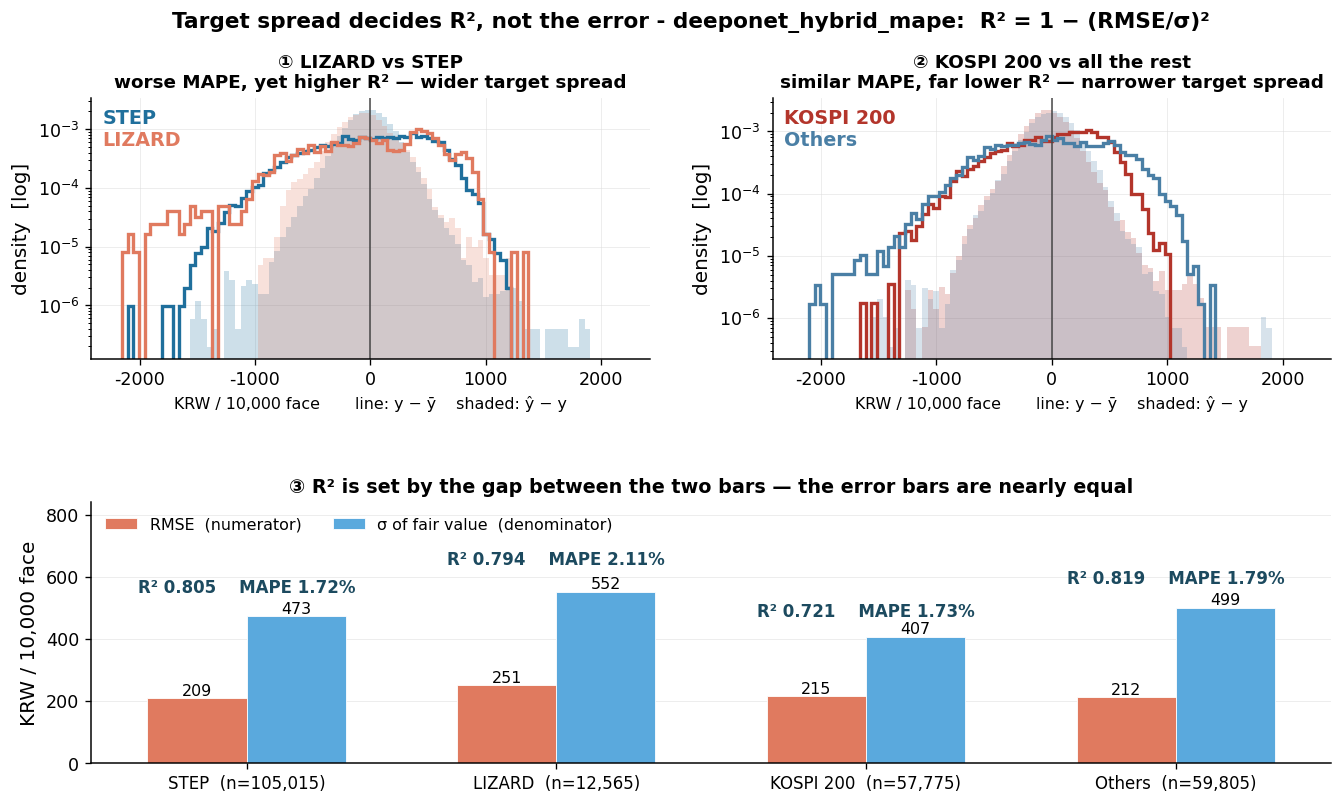

=== 세그먼트별 (공통 σ = 483원) ===
                     n       sd     rmse   mape     r2  r2_common
seg                                                              
STEP x KI        43540  497.592  232.183  1.912  0.782      0.769
STEP x no-KI     61475  453.639  190.607  1.581  0.823      0.844
LIZARD x KI       3275  591.779  240.292  2.020  0.835      0.753
LIZARD x no-KI    9290  533.999  254.253  2.143  0.773      0.723
S&P 500         101410  487.142  207.230  1.715  0.819      0.816
HSCEI            40125  482.403  215.755  1.797  0.800      0.800
SK hynix          1810  701.484  288.830  2.633  0.830      0.642
Samsung Elec.     2255  588.327  264.538  2.431  0.798      0.700
Hang Seng          480  198.810  200.075  1.518 -0.013      0.828
KOSPI 200        57775  406.890  215.064  1.728  0.721      0.802
Hyundai Motor      410  795.148  311.633  2.984  0.846      0.584
NAVER              575  787.322  335.266  3.000  0.819      0.518
LG Chem            655  430.302  259.947  2.234 

In [16]:
# 그림 10b: 타깃 편차(target deviation)가 R²를 결정한다 — 리자드·KOSPI200 두 역설
from scipy.stats import pearsonr

dS = M[M.model == STAGE_MODEL].copy()
CLR = {"STEP": "#1f6f9c", "LIZARD": "#e07a5f",
       "KOSPI 200": "#b3352b", "Others": "#4a7fa5"}


def _stat(s):
    """R² = 1 − (RMSE/σ)² 의 분자·분모를 원 단위로."""
    e = (s.y_pred - s.y_true).values * FACE
    dev = (s.y_true - s.y_true.mean()).values * FACE
    sd = float(np.sqrt((dev ** 2).mean())); rmse = float(np.sqrt((e ** 2).mean()))
    return dict(n=len(s), dev=dev, err=e, sd=sd, rmse=rmse, r2=1 - (rmse / sd) ** 2,
                mape=float((np.abs(e) / (s.y_true.values * FACE)).mean() * 100))


def _tk(t):
    return dS[(dS.udl1 == t) | (dS.udl2 == t) | (dS.udl3 == t)]


_hasks = (dS.udl1 == "^KS200") | (dS.udl2 == "^KS200") | (dS.udl3 == "^KS200")
G = {"STEP": _stat(dS[dS.opt_type == "STEP"]), "LIZARD": _stat(dS[dS.opt_type == "LIZARD"]),
     "KOSPI 200": _stat(dS[_hasks]), "Others": _stat(dS[~_hasks])}

fig = plt.figure(figsize=(_plot.SLIDE_W, 7.2))
gs = fig.add_gridspec(2, 2, hspace=0.55, wspace=0.22)


def dev_panel(a, keys, title):
    """타깃 편차(선) + 잔차(음영), 로그 밀도. 범례 없이 색으로 구분."""
    for kk in keys:
        g = G[kk]
        a.hist(g["dev"], bins=90, range=(-2200, 2200), histtype="step", linewidth=2.0,
               color=CLR[kk], density=True, log=True)
        a.hist(g["err"], bins=90, range=(-2200, 2200), histtype="stepfilled", linewidth=0,
               color=CLR[kk], alpha=0.22, density=True, log=True)
    a.axvline(0, color="#444", lw=0.9)
    for j, kk in enumerate(keys):          # 색 대응만 (수치는 ③ 패널과 아래 표에)
        a.text(0.02, 0.96 - 0.085 * j, kk, transform=a.transAxes, ha="left", va="top",
               fontsize=11.5, fontweight="bold", color=CLR[kk])
    a.set_xlabel("KRW / 10,000 face       line: y − ȳ    shaded: ŷ − y", fontsize=9.5)
    a.set_ylabel("density  [log]")
    a.set_title(title, fontsize=11)
    a.grid(color="#dddddd", lw=0.5, alpha=0.6)


dev_panel(fig.add_subplot(gs[0, 0]), ["STEP", "LIZARD"],
          "① LIZARD vs STEP\nworse MAPE, yet higher R² — wider target spread")
dev_panel(fig.add_subplot(gs[0, 1]), ["KOSPI 200", "Others"],
          "② KOSPI 200 vs all the rest\nsimilar MAPE, far lower R² — narrower target spread")

# ③ 분자 vs 분모
a = fig.add_subplot(gs[1, :])
KS = list(G); x = np.arange(len(KS)); w = 0.32
rm = [G[k]["rmse"] for k in KS]; sg = [G[k]["sd"] for k in KS]
a.bar(x - w / 2, rm, w, label="RMSE  (numerator)", color="#e07a5f", edgecolor="white", linewidth=0.5)
a.bar(x + w / 2, sg, w, label="σ of fair value  (denominator)", color="#5aa9dd",
      edgecolor="white", linewidth=0.5)
for i, kk in enumerate(KS):
    a.text(i - w / 2, rm[i], f"{rm[i]:.0f}", ha="center", va="bottom", fontsize=9.5)
    a.text(i + w / 2, sg[i], f"{sg[i]:.0f}", ha="center", va="bottom", fontsize=9.5)
    a.text(i, max(rm[i], sg[i]) * 1.16, f"R² {G[kk]['r2']:.3f}    MAPE {G[kk]['mape']:.2f}%",
           ha="center", fontsize=10, fontweight="bold", color="#1c4a5f")
a.set_xticks(x); a.set_xticklabels([f"{k}  (n={G[k]['n']:,})" for k in KS], fontsize=10)
a.set_ylabel("KRW / 10,000 face"); a.set_ylim(0, max(sg) * 1.52)
a.set_title("③ R² is set by the gap between the two bars — the error bars are nearly equal",
            fontsize=11.5)
a.legend(fontsize=9.5, loc="upper left", ncol=2, framealpha=0.95)
a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Target spread decides R², not the error - {STAGE_MODEL}:  R² = 1 − (RMSE/σ)²",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.955))
fig.savefig(fm.image("seg_target_spread_r2"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

# 전 세그먼트 근거 (그림에는 넣지 않고 표·상관으로)
ROWS = []
for st in STRUCTS:
    ROWS.append(dict(seg=st, **{q: v for q, v in _stat(dS[dS.struct == st]).items()
                                if q not in ("dev", "err")}))
for t in pd.unique(pd.concat([dS.udl1, dS.udl2, dS.udl3]).dropna()):
    s = _tk(t)
    if len(s) >= 200:
        ROWS.append(dict(seg=uname(t), **{q: v for q, v in _stat(s).items()
                                          if q not in ("dev", "err")}))
SEGT = pd.DataFrame(ROWS).set_index("seg")
SD_ALL = float((dS.y_true - dS.y_true.mean()).std(ddof=0) * FACE)
SEGT["r2_common"] = 1 - (SEGT.rmse / SD_ALL) ** 2
SEGT.round(4).to_csv(fm.stat("seg_spread_r2"))

print(f"=== 세그먼트별 (공통 σ = {SD_ALL:.0f}원) ===")
print(SEGT[["n", "sd", "rmse", "mape", "r2", "r2_common"]].round(3).to_string())
print("\n두 역설")
print(f"  LIZARD   MAPE {G['LIZARD']['mape']:.3f}% > STEP {G['STEP']['mape']:.3f}% (나쁨) 인데 "
      f"R² {G['LIZARD']['r2']:.3f} > {G['STEP']['r2']:.3f} (좋음)  ← σ {G['LIZARD']['sd']:.0f} vs {G['STEP']['sd']:.0f}원")
_o = "Others"
print(f"  KOSPI200 MAPE {G['KOSPI 200']['mape']:.3f}% vs 그 외 {G[_o]['mape']:.3f}% (거의 같음) 인데 "
      f"R² {G['KOSPI 200']['r2']:.3f} vs {G[_o]['r2']:.3f} (0.2 이상 차)  "
      f"← σ {G['KOSPI 200']['sd']:.0f} vs {G[_o]['sd']:.0f}원")
print("\n전 세그먼트 상관 (R² 가 무엇을 따라가나)")
for nm, col in (("σ", "sd"), ("MAPE", "mape"), ("RMSE", "rmse")):
    r = pearsonr(SEGT[col], SEGT.r2)
    print(f"  R²(자체 σ) vs {nm:5s} r={r[0]:+.3f} (p={r[1]:.3f})")
r = pearsonr(SEGT.mape, SEGT.r2_common)
print(f"  R²(공통 σ) vs MAPE  r={r[0]:+.3f} (p={r[1]:.4f})  ← 분모 고정 시 부호가 뒤집혀 정상화")
print("saved ->", fm.image("seg_target_spread_r2").name, "|", fm.stat("seg_spread_r2").name)

### 5-5c. 리자드의 σ 가 왜 더 큰가 — 연도평균 진폭이 주범

σ 는 세그먼트 내 상품 간 산포다. 발행연도로 갈라 세 조각으로 분해한다.

```
σ²_total = within(연도내 산포)  +  between(연도평균 산포)
between  은 다시  연도 가중치(구성)  와  연도평균 자체의 진폭  으로 나뉜다
```

| 요인 | 분산 기여 | 비중 |
|---|---|---|
| ① 연도 내 산포 | 11,270 | 13.8% |
| ② 연도 가중치 (표본이 어느 해에 몰렸나) | 20,502 | 25.2% |
| **③ 연도평균 진폭 (해마다 가격 수준이 얼마나 움직였나)** | **49,636** | **61.0%** |

**추세는 STEP 도 겪는다. 차이는 기울기다** — 연도평균 진폭이 STEP 765원 vs LIZARD **1,073원 (1.40배)**.
리자드는 2021년에 STEP 보다 292원 싸다가 2026년엔 16원 비싸진다(연도평균 표준오차 17~20원이라 잡음이 아니다).

배경은 **계약 관행의 변화 폭**이다. LIZARD − STEP 차이가 2021 → 2026 으로 이렇게 벌어진다:
노낙인 비중 +0.139 → +0.331, 관측 회차수 −0.05 → +1.08(7.76 vs 6.68회),
만기 행사가 −0.011 → −0.068(낮을수록 상환 쉬움), stepdown +0.028 → +0.097.
**넷 다 리자드 가격을 상대적으로 밀어올리는 방향**이다. 같은 기간 STEP 은 이 항목들이 거의 평평하다.

즉 리자드 σ 가 큰 건 payoff 구조가 다양해서가 아니라, **표본(n=2,513, STEP 의 12%) 안에 시대별로
계약 관행이 크게 다른 상품이 섞여 있어서**다. **연도 내에서 재면 산포는 STEP 과 사실상 같다.**

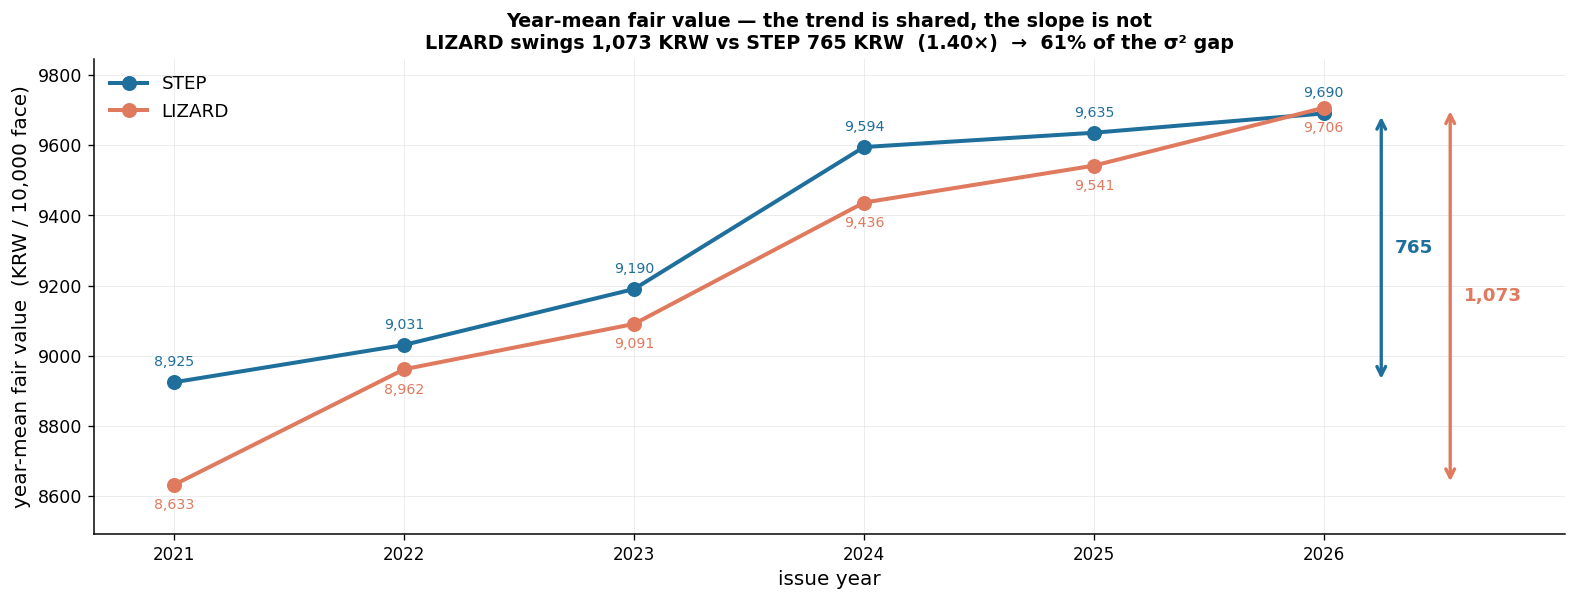

=== 발행연도 × 구조 ===
       STEP_n  STEP_mean  STEP_sd  STEP_w%  LIZARD_n  LIZARD_mean  LIZARD_sd  LIZARD_w%  gap(L-S)  sd_ratio
iyear                                                                                                      
2021    19440     8924.8    470.6     18.5      3430       8633.1      517.5       27.3    -291.7       1.1
2022    26090     9031.0    409.8     24.8      2435       8961.7      401.8       19.4     -69.3       1.0
2023    25455     9190.1    379.8     24.2      1705       9090.7      410.6       13.6     -99.5       1.1
2024    14340     9594.4    295.0     13.7      1165       9436.2      267.5        9.3    -158.2       0.9
2025    15010     9635.1    295.9     14.3      2665       9541.5      274.5       21.2     -93.6       0.9
2026     4680     9690.0    255.3      4.5      1165       9706.1      262.3        9.3      16.1       1.0

연도평균 진폭  STEP 765원  LIZARD 1073원  (1.40배)
σ 경로  between: STEP가중·STEP평균 279.9 → LIZARD가중·STEP평균 314.4 → LIZARD가중·LIZAR

In [17]:
# 그림 10c: LIZARD σ 의 정체 — 연도평균 진폭 vs 연도내 산포 vs 분산 3원 분해
_yr = pd.read_parquet(fm.source())[["item", "isu_ord"]]
_yr["ITEM_CD"] = _yr.pop("item").astype(str)
_yr["iyear"] = _yr.isu_ord.apply(lambda o: pd.Timestamp.fromordinal(int(o)).year)
dY = dS.merge(_yr[["ITEM_CD", "iyear"]], on="ITEM_CD", how="left")
dY["fair"] = dY.y_true * FACE
YR = sorted(dY.iyear.unique())
C2 = {"STEP": "#1f6f9c", "LIZARD": "#e07a5f"}


def yr_stats(g):
    s = dY[dY.opt_type == g]
    return (s.groupby("iyear").fair.mean().reindex(YR),
            s.groupby("iyear").fair.std(ddof=0).reindex(YR),
            s.groupby("iyear").size().reindex(YR).fillna(0) / len(s))


mS, sdS, wS = yr_stats("STEP")
mL, sdL, wL = yr_stats("LIZARD")


def _btw(m, w):
    mu = float(np.nansum(w * m)); return float(np.sqrt(np.nansum(w * (m - mu) ** 2)))


def _wtn(sd, w):
    return float(np.sqrt(np.nansum(w * sd ** 2)))


tS = float(dY[dY.opt_type == "STEP"].fair.std(ddof=0))
tL = float(dY[dY.opt_type == "LIZARD"].fair.std(ddof=0))
bSS, bLS, bLL = _btw(mS, wS), _btw(mS, wL), _btw(mL, wL)
wSS, wLL = _wtn(sdS, wS), _wtn(sdL, wL)
gapv = tL ** 2 - tS ** 2
PART = [("within-year\nspread", wLL ** 2 - wSS ** 2, "#9bb7c9"),
        ("year weights\n(sample mix)", bLS ** 2 - bSS ** 2, "#5aa9dd"),
        ("year-mean\namplitude", bLL ** 2 - bLS ** 2, "#e07a5f")]

_ratio = sdL / sdS                     # 연도내 sigma 비 (LIZARD/STEP)

fig, a = plt.subplots(figsize=(_plot.SLIDE_W, _plot.BAND_H))   # PPT 콘텐츠 밴드 규격
x = np.arange(len(YR))
for nm, m in (("STEP", mS), ("LIZARD", mL)):
    a.plot(x, m.values, "o-", lw=2.4, ms=8, color=C2[nm], label=nm)
    for i, v in enumerate(m.values):
        a.text(x[i], v + (38 if nm == "STEP" else -38), f"{v:,.0f}", ha="center",
               va="bottom" if nm == "STEP" else "top", fontsize=8.5, color=C2[nm])
for j, (nm, m) in enumerate((("STEP", mS), ("LIZARD", mL))):   # 진폭 화살표 두 개를 나란히
    xa = len(YR) - 0.75 + 0.30 * j
    a.annotate("", xy=(xa, m.max()), xytext=(xa, m.min()),
               arrowprops=dict(arrowstyle="<->", color=C2[nm], lw=2.0))
    a.text(xa + 0.06, (m.max() + m.min()) / 2, f"{m.max()-m.min():,.0f}",
           color=C2[nm], fontsize=11, fontweight="bold", va="center", ha="left")
a.set_xticks(x); a.set_xticklabels(YR, fontsize=10)
a.set_xlim(-0.35, len(YR) + 0.05); a.margins(y=0.13)
a.set_xlabel("issue year"); a.set_ylabel("year-mean fair value  (KRW / 10,000 face)")
a.set_title(f"Year-mean fair value — the trend is shared, the slope is not\n"
            f"LIZARD swings {mL.max()-mL.min():,.0f} KRW vs STEP {mS.max()-mS.min():,.0f} KRW  "
            f"({(mL.max()-mL.min())/(mS.max()-mS.min()):.2f}×)  →  "
            f"{PART[2][1]/gapv:.0%} of the σ² gap", fontsize=11.5, fontweight="bold")
a.legend(fontsize=11, loc="upper left"); a.grid(color="#dddddd", lw=0.5, alpha=0.6)
fig.tight_layout()
fig.savefig(fm.image("seg_lizard_variance_year"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

YT = pd.DataFrame({"STEP_n": dY[dY.opt_type == "STEP"].groupby("iyear").size().reindex(YR),
                   "STEP_mean": mS, "STEP_sd": sdS, "STEP_w%": wS * 100,
                   "LIZARD_n": dY[dY.opt_type == "LIZARD"].groupby("iyear").size().reindex(YR),
                   "LIZARD_mean": mL, "LIZARD_sd": sdL, "LIZARD_w%": wL * 100,
                   "gap(L-S)": mL - mS, "sd_ratio": _ratio})
YT.round(1).to_csv(fm.stat("seg_lizard_year"))
print("=== 발행연도 × 구조 ===")
print(YT.round(1).to_string())
print(f"\n연도평균 진폭  STEP {mS.max()-mS.min():.0f}원  LIZARD {mL.max()-mL.min():.0f}원  "
      f"({(mL.max()-mL.min())/(mS.max()-mS.min()):.2f}배)")
print(f"σ 경로  between: STEP가중·STEP평균 {bSS:.1f} → LIZARD가중·STEP평균 {bLS:.1f} "
      f"→ LIZARD가중·LIZARD평균 {bLL:.1f}   |   within: {wSS:.1f} → {wLL:.1f}")
print(f"\n분산 격차 {gapv:,.0f} 의 구성")
for nm, v, _ in PART:
    print(f"   {nm.replace(chr(10), ' '):28s} {v:9,.0f}  ({v/gapv:5.1%})")
print("saved ->", fm.image("seg_lizard_variance_year").name, "|", fm.stat("seg_lizard_year").name)

## 5-6. KOSPI200 이 들어가면 왜 성능이 낮게 보이나 — 상관·변동성 관점

지수별 판(그림 5·9)에서 `KS200` 의 최종 R² 가 **0.538 로 가장 낮다**. 원인을 **변동성**과 **상관**으로 분해한다.

- **변동성은 원인이 아니다.** KS200 의 180일 역사변동성은 **16.6%** 로 GSPC(16.4%) 와 사실상 같고
  STOXX50E(18.3%)·N225(19.8%)·HSCE(23.9%) 보다 오히려 **낮다**. 바스켓 `sig_eff` 도 0.235 vs 0.238 로 차이가 없다.
- **상관이 원인이다.** KS200 은 아시아 지수와 강하게 붙어 있다 — HSCEI **0.57** · Nikkei 225 **0.59**.
  반면 S&P 500 은 아시아와 거의 무상관(0.20)이다. KS200 이 낀 쌍의 평균 상관은 **0.42**,
  안 낀 쌍은 **0.34** 다(그림 11 왼쪽. Hang Seng 은 HSCEI 와 상관 0.96 으로 중복이라 히트맵에서 제외). 그래서 KS200 을 넣은 바스켓의 평균 상관은 **0.312**,
  안 넣은 바스켓은 0.287 이다(OOS 표본 기준. 전량 기준으로는 0.358 vs 0.344).
- **상관이 높으면 worst-of 의 분산이 줄어든다.** 세 자산이 같이 움직일수록 "가장 나쁜 하나"가 극단으로
  벌어질 여지가 작다. 그 결과 공정가가 **더 높고(0.938 vs 0.923) 더 좁게 뭉친다(σ 407 vs 499원)**.
- **R² 는 그 좁아진 분산으로 나눈다.** 실제 오차는 RMSE 277 vs 252원, MAPE **2.22% vs 2.16%** 로 거의 같은데
  분모가 18% 좁아 R² 만 0.538 vs 0.744 로 벌어진다. 공통 분모(전체 OOS σ=483원)로 다시 재면
  **0.672 vs 0.727** — 격차가 0.206 에서 **0.055** 로 줄어든다.

- **표본 전체에서 같은 관계가 확인된다.** 상품을 바스켓 상관 ρ 6분위로 나누면(그림 11 오른쪽)
  ρ 가 오를수록 **분모 σ 가 550 → 442원(−20%)** 으로 줄고 R² 는 **0.800 → 0.468** 로 떨어진다.
  같은 구간에서 KOSPI200 포함 비중은 49% → 64% 로 오른다. 이 구간 비교에서는 분자(RMSE)도
  246 → 322원(+31%)으로 함께 늘어난다 — 상관이 높은 바스켓은 실제로 조금 더 어렵다.
  다만 KOSPI200 포함/미포함 이라는 축으로만 자르면 분자 차이는 277 vs 252원으로 작다.

**결론**: "KS200 이 들어가면 안 좋다"의 **약 73% 는 R² 분모 착시**다. 남은 27% 는 진짜이고
`STEP×KI` 한 칸에 몰려 있다(MAPE 2.62% vs 2.15%). 세그먼트 비교는 5-5 와 같은 이유로 **MAPE·RMSE 로 해야 한다**.

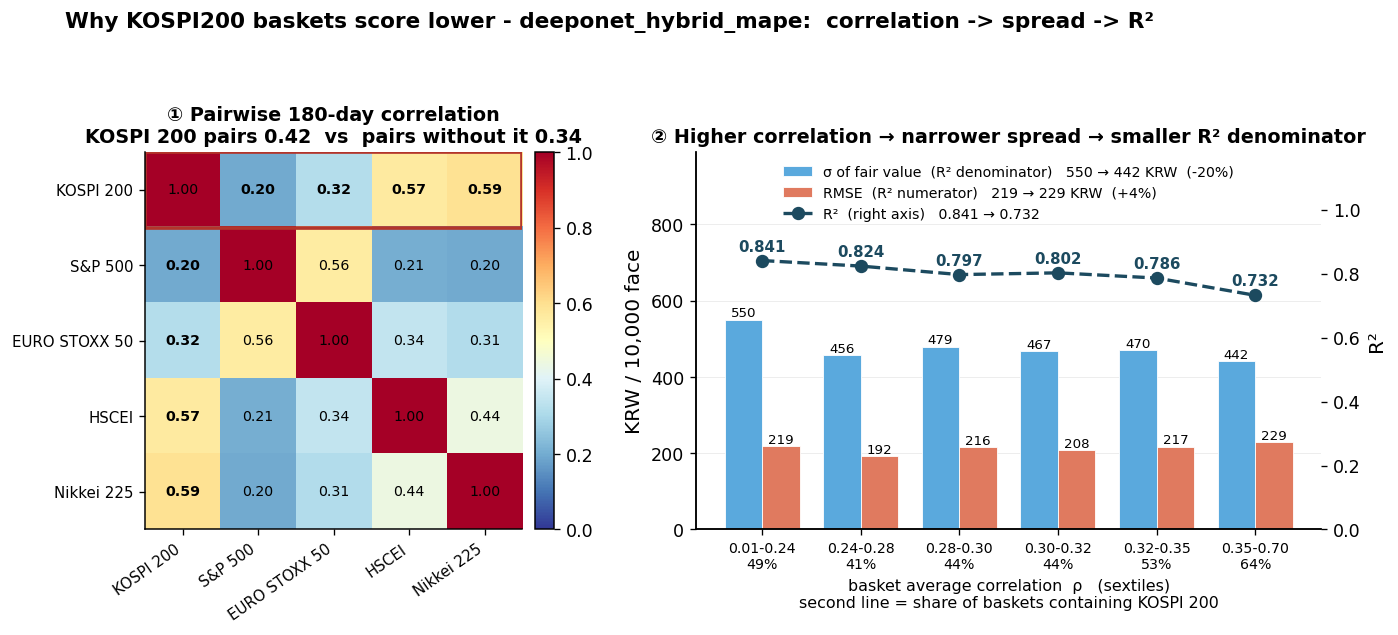

=== ρ 구간별 (R² = 1 - (RMSE/σ)²) ===
   lo    hi   rho     n    ks    RMSE      SD    R2  MAPE
0.011 0.238 0.193 19600 0.489 219.233 549.609 0.841 1.775
0.238 0.277 0.259 19645 0.411 191.572 456.148 0.824 1.581
0.277 0.305 0.291 19545 0.437 215.919 479.198 0.797 1.765
0.305 0.324 0.314 19600 0.443 207.590 467.039 0.802 1.750
0.324 0.353 0.337 19595 0.528 217.406 470.162 0.786 1.791
0.353 0.696 0.404 19595 0.640 228.743 441.947 0.732 1.899

=== KOSPI200 포함 여부 (공통 σ = 483원) ===
        group   rho     n    RMSE      SD    R2  MAPE  R2_common
 KOSPI 200 in 0.312 57775 215.064 406.890 0.721 1.728      0.802
KOSPI 200 out 0.287 59805 212.401 499.256 0.819 1.792      0.807

=== 구조 통제 ===
        struct            KS     n    RMSE      SD    R2  MAPE
   LIZARD x KI  KOSPI 200 in  1375 230.990 311.824 0.451 1.845
   LIZARD x KI KOSPI 200 out  1900 246.805 649.628 0.856 2.147
LIZARD x no-KI  KOSPI 200 in  4650 252.629 463.173 0.703 2.117
LIZARD x no-KI KOSPI 200 out  4640 255.870 505.364 0.744 2.

In [18]:
# 그림 11: 상관이 높으면 R² 분모(공정가 σ)가 좁아진다 — 히트맵 + ρ 구간 분해
# 히트맵 지수 5개. ^HSI(Hang Seng)는 ^HSCE 와 상관 0.96 으로 사실상 중복이고 표본도 작아 제외.
MAIN = ["^KS200", "^GSPC", "^STOXX50E", "^HSCE", "^N225"]
CIN, COUT, RD = "#e07a5f", "#1f6f9c", "#b3352b"


def _logret(t):
    p = fm.CACHE / ("px_" + t.replace("^", "_").replace(".", "_") + ".parquet")
    s = pd.read_parquet(p)["close"].dropna().sort_index()
    return np.log(s[~s.index.duplicated()]).diff()


# 데이터셋과 같은 정의(180일 역사) 로 지수쌍 상관
X = pd.DataFrame({t: _logret(t) for t in MAIN}).sort_index().loc["2015":"2024"]
VOL = (X.rolling(180, min_periods=120).std() * np.sqrt(252)).mean()
_C = X.rolling(180, min_periods=120).corr()
CM = pd.DataFrame([[_C.xs(a, level=1)[b].mean() for b in MAIN] for a in MAIN], index=MAIN, columns=MAIN)

# 상품 단위 (KOSPI200 포함 여부 + 바스켓 평균 상관)
K = M[M.model == STAGE_MODEL].copy()
K["KS"] = np.where((K.udl1 == "^KS200") | (K.udl2 == "^KS200") | (K.udl3 == "^KS200"),
                   "KOSPI 200 in", "KOSPI 200 out")
_x = pd.read_parquet(fm.source())[["item", "rho", "sig_eff"]]
_x["ITEM_CD"] = _x.pop("item").astype(str)
K = K.merge(_x, on="ITEM_CD", how="left")


def _cell(s):
    e = (s.y_pred - s.y_true).values * FACE
    rmse = float(np.sqrt((e ** 2).mean()))
    sd = float((s.y_true - s.y_true.mean()).std(ddof=0) * FACE)
    return dict(n=len(s), RMSE=rmse, SD=sd, R2=1 - (rmse / sd) ** 2,
                MAPE=float((np.abs(e) / (s.y_true.values * FACE)).mean() * 100))


NBIN = 6
K["rho_bin"] = pd.qcut(K.rho, NBIN, duplicates="drop")
B = pd.DataFrame([{"lo": b.left, "hi": b.right, "rho": s.rho.mean(),
                   "ks": float((s.KS == "KOSPI 200 in").mean()), **_cell(s)}
                  for b, s in K.groupby("rho_bin", observed=True)])

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.4))

# ① 지수쌍 상관 — KOSPI200 은 아시아와 강하게 붙어 있다
a = ax[0]
im = a.imshow(CM.values, cmap="RdYlBu_r", vmin=0, vmax=1)
a.set_xticks(range(len(MAIN))); a.set_yticks(range(len(MAIN)))
a.set_xticklabels([uname(t) for t in MAIN], fontsize=9, rotation=35, ha="right")
a.set_yticklabels([uname(t) for t in MAIN], fontsize=9)
for i in range(len(MAIN)):
    for j in range(len(MAIN)):
        a.text(j, i, f"{CM.values[i,j]:.2f}", ha="center", va="center", fontsize=8.5,
               fontweight="bold" if (i == 0 or j == 0) and i != j else "normal")
a.add_patch(plt.Rectangle((-0.5, -0.5), len(MAIN), 1, fill=False, ec=RD, lw=2.2))
_o = [t for t in MAIN if t != "^KS200"]
_ks = float(CM.loc["^KS200", _o].mean())
_no = float(np.mean([CM.loc[p, q] for i, p in enumerate(_o) for q in _o[i + 1:]]))
a.set_title(f"① Pairwise 180-day correlation\n"
            f"KOSPI 200 pairs {_ks:.2f}  vs  pairs without it {_no:.2f}", fontsize=11.5)
fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)

# ② 상관이 오를수록 R² 분모(공정가 σ)가 좁아진다
a = ax[1]
xb = np.arange(len(B)); w = 0.38


def _delta(v):                                   # 첫 구간 → 마지막 구간 변화
    return f"{v.iloc[0]:.0f} → {v.iloc[-1]:.0f} KRW  ({v.iloc[-1]/v.iloc[0]-1:+.0%})"


b1 = a.bar(xb - w / 2, B.SD, w, color="#5aa9dd", edgecolor="white", linewidth=0.5,
           label=f"σ of fair value  (R² denominator)   {_delta(B.SD)}")
b2 = a.bar(xb + w / 2, B.RMSE, w, color="#e07a5f", edgecolor="white", linewidth=0.5,
           label=f"RMSE  (R² numerator)   {_delta(B.RMSE)}")
for r, v in list(zip(b1, B.SD)) + list(zip(b2, B.RMSE)):
    a.text(r.get_x() + r.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
a.set_ylabel("KRW / 10,000 face"); a.set_ylim(0, B.SD.max() * 1.80)
a.set_xticks(xb)
a.set_xticklabels([f"{lo:.2f}-{hi:.2f}\n{k:.0%}" for lo, hi, k in zip(B.lo, B.hi, B.ks)],
                  fontsize=8.5)
a.set_xlabel("basket average correlation  ρ   (sextiles)\n"
             "second line = share of baskets containing KOSPI 200", fontsize=9.5)
a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

a2 = a.twinx()
a2.plot(xb, B.R2, "o--", color="#1c4a5f", lw=2.0, ms=7,
        label=f"R²  (right axis)   {B.R2.iloc[0]:.3f} → {B.R2.iloc[-1]:.3f}")
for i, v in enumerate(B.R2):
    a2.text(xb[i], v + 0.030, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold", color="#1c4a5f")
a2.set_ylabel("R²"); a2.set_ylim(0, 1.18); a2.grid(False)

h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="upper center", framealpha=0.95)
a.set_title("② Higher correlation → narrower spread → smaller R² denominator", fontsize=11.5)

fig.suptitle(f"Why KOSPI200 baskets score lower - {STAGE_MODEL}:  correlation -> spread -> R²",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_ks200_correlation"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

# 표: ρ 구간 / KOSPI200 포함 여부 / 구조 통제
B.round(3).to_csv(fm.stat("seg_rho_bins"), index=False)
print("=== ρ 구간별 (R² = 1 - (RMSE/σ)²) ===")
print(B[["lo", "hi", "rho", "n", "ks", "RMSE", "SD", "R2", "MAPE"]].round(3).to_string(index=False))

sd_K = float((K.y_true - K.y_true.mean()).std(ddof=0) * FACE)
print(f"\n=== KOSPI200 포함 여부 (공통 σ = {sd_K:.0f}원) ===")
rows = []
for g, s in K.groupby("KS"):
    c = _cell(s)
    rows.append(dict(group=g, rho=s.rho.mean(), **c, R2_common=1 - (c["RMSE"] / sd_K) ** 2))
KS_G = pd.DataFrame(rows)
print(KS_G.round(3).to_string(index=False))

rows = []
for (st_, g), s in K.groupby(["struct", "KS"]):
    if len(s) >= 100:
        rows.append(dict(struct=st_, KS=g, **_cell(s)))
KS_T = pd.DataFrame(rows)
KS_T.to_csv(fm.stat("seg_ks200"), index=False)
print("\n=== 구조 통제 ===")
print(KS_T.round(3).to_string(index=False))
print(f"\n지수별 180일 역사변동성(%): "
      f"{ {uname(t): round(v*100, 2) for t, v in VOL.sort_values().items()} }")
print("saved ->", fm.image("seg_ks200_correlation").name, "|",
      fm.stat("seg_ks200").name, "|", fm.stat("seg_rho_bins").name)

## 5-7. 리자드 24열은 값을 하나? — trunk ablation (STEP 기준)

### 왜 24열인가

리자드는 **회차마다** 배리어와 축소 지급률이 따로 있어서, 오토콜 스케줄과 같은 **12회차 고정폭**을 두 벌 깔았다.

```
lz_barr_0..11  (12)  리자드 배리어      +  lz_pmt_0..11  (12)  리자드 축소 지급률   = 24열
```

**그런데 실제 데이터는 그 폭을 거의 안 쓴다.**

| 회차 | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8~11 |
|---|---|---|---|---|---|---|---|---|---|
| LIZARD 상품 중 비결측 % | 66.9 | **94.7** | 14.8 | 5.3 | 4.0 | 0.04 | 0.02 | 0.02 | **0** |

- 리자드 회차 수는 상품당 **1~3회가 99%** (2회 6,257건 · 1회 3,726건 · 3회 1,440건).
- `lz_barr_8..11`·`lz_pmt_8..11` **8열은 전 표본에서 완전히 비어 있다** → 중립값 상수.
- **STEP 상품(표본의 80%)에서는 24열 전부가 상수**(`lz_barr=1.2`, `lz_pmt=0`)다.

즉 24는 **데이터가 요구한 크기가 아니라 스케줄 레이아웃을 그대로 두 벌 복사한 결과**다.
정보를 담은 건 사실상 회차 0~4 의 10열이다.

### ablation 설계

리자드 열은 **stage-1 앵커(DeepONet trunk = `D.CON`)로만** 들어간다.
stage-2 기본 잔차모델(`ml_resid`)은 ml 특성(BASE+REG+CAT)을 쓰고 `lz_*` 를 보지 않는다.
그래서 `D.CON` 에서 24열만 떼고 **같은 시드·같은 코드경로로 다시 학습**하면 순수 ablation이 된다.
비교 모델은 `deeponet_hybrid_mape` (앵커 MAPE loss).

**단계별로 본다.** 리자드 열이 직접 들어가는 곳은 stage-1(앵커)뿐이므로 stage-1 이 1차 효과,
stage-2·final 은 그 파급이다. 세 단계를 나란히 두면 "앵커가 나빠졌는데 최종은 왜 좋아졌나"까지 읽힌다.

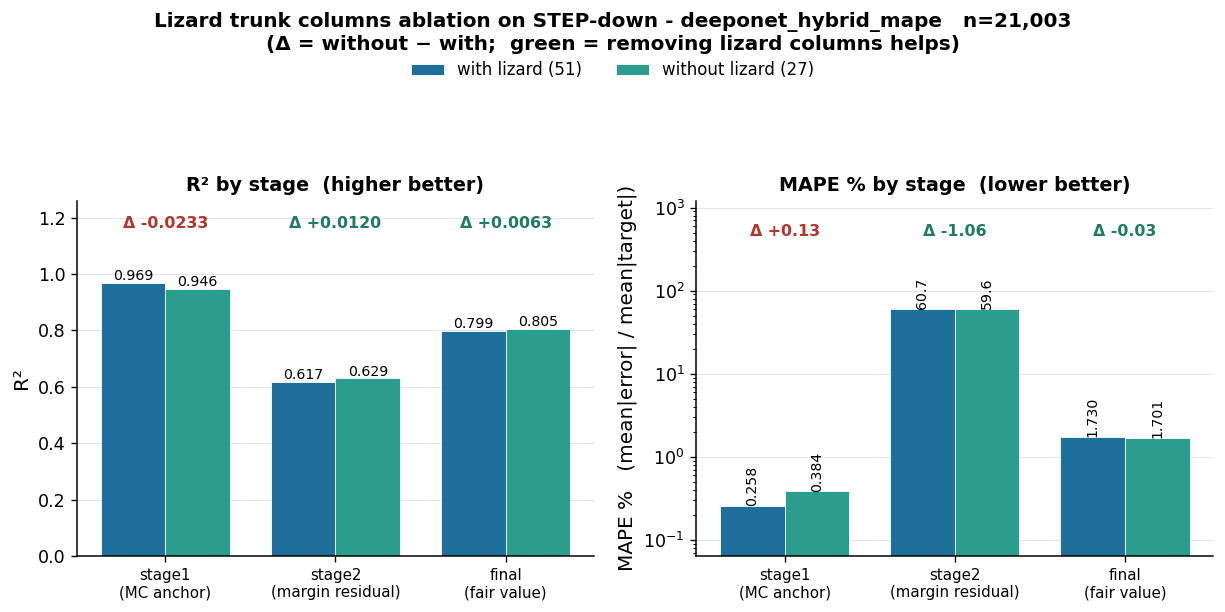

=== 리자드 24열 ablation — 그림은 STEP (all) (Δ = without − with) ===
                  n  stage1R2_with  stage1R2_without  stage1R2_Δ  stage2R2_with  stage2R2_without  stage2R2_Δ  finalR2_with  finalR2_without  finalR2_Δ
seg                                                                                                                                                    
STEP x KI      8708         0.9600            0.9366     -0.0234         0.5366            0.5560      0.0194        0.7745           0.7776     0.0031
STEP x no-KI  12295         0.9814            0.9577     -0.0237         0.6769            0.6857      0.0088        0.8192           0.8283     0.0091
STEP (all)    21003         0.9693            0.9460     -0.0233         0.6172            0.6292      0.0120        0.7988           0.8052     0.0063
LIZARD (all)   2513         0.8476            0.5596     -0.2880         0.4396            0.4478      0.0082        0.7910           0.7517    -0.0394
ALL           23516      

In [19]:
# 그림 12: 리자드 24열 ablation — STEP-down 전체, 단계별 R² · MAPE (같은 시드 재학습, 약 1분)
FORCE_ABL = False                       # True 로 두면 CSV 가 있어도 다시 학습
_ap = fm.stat("ablation_lizard_cols")
_need = ["stage1_R2", "stage2_R2", "final_R2", "stage1_MAPE", "stage2_MAPE", "final_MAPE"]
_stale = (not _ap.exists()) or any(c not in pd.read_csv(_ap, nrows=1).columns for c in _need)

if FORCE_ABL or _stale:
    import time
    from module import data as _DA
    from module.pipeline import predict_hybrid
    from model.deeponet import _anchor_mape

    _CON = list(_DA.CONTRACT)
    _keep = [j for j, c in enumerate(_CON) if not c.startswith("lz_")]
    _full = D.CON.copy()
    _src = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn"]]
    _src["ITEM_CD"] = _src.pop("item").astype(str)
    _src["struct"] = _src.opt_type + " x " + np.where(_src.ki_yn == 1, "KI", "no-KI")
    _SEG = [("STEP x KI", lambda z: z.struct == "STEP x KI"),
            ("STEP x no-KI", lambda z: z.struct == "STEP x no-KI"),
            ("STEP (all)", lambda z: z.opt_type == "STEP"),
            ("LIZARD (all)", lambda z: z.opt_type == "LIZARD"),
            ("ALL", lambda z: z.index == z.index)]
    _rows = []
    for _arm, _cols in (("with lizard (51)", None), ("without lizard (27)", _keep)):
        D.CON = _full if _cols is None else np.ascontiguousarray(_full[:, _cols])
        D.DON = np.concatenate([D.CURVE, D.VC, D.CON], axis=1).astype("float32")
        _t = time.time()
        _p = predict_hybrid(D, cfg, _anchor_mape, target=D.FAIR, use_margin=True)
        _p["ITEM_CD"] = _p["ITEM_CD"].astype(str)
        _p = _p.merge(_src, on="ITEM_CD", how="left")
        print(f"[{_arm}] trunk {D.CON.shape[1]}열 | {time.time()-_t:.0f}s")
        for _nm, _f in _SEG:
            _s = _p[_f(_p)]
            _r = dict(arm=_arm, seg=_nm, n=len(_s))
            for _sn, _tc, _pc in STAGES_TP:                       # 단계별 R²·MAPE (자기 타깃 분모)
                _e = np.abs((_s[_pc] - _s[_tc]).values)
                _r[f"{_sn}_R2"] = r2_score(_s[_tc], _s[_pc])
                _r[f"{_sn}_MAPE"] = float(_e.mean() / _s[_tc].abs().mean() * 100)
                _r[f"{_sn}_RMSE"] = float(np.sqrt((_e ** 2).mean()) * FACE)
            _r["R2"], _r["MAPE"] = _r["final_R2"], _r["final_MAPE"]
            _rows.append(_r)
    D.CON = _full
    D.DON = np.concatenate([D.CURVE, D.VC, D.CON], axis=1).astype("float32")
    pd.DataFrame(_rows).to_csv(_ap, index=False)

A = pd.read_csv(_ap)
ARMS = ["with lizard (51)", "without lizard (27)"]
SEG1 = "STEP (all)"                                   # 원래 분석 대상인 스텝다운 전체
W = A[A.seg == SEG1].set_index("arm").reindex(ARMS)
NN = int(W["n"].iloc[0])
STG = [("stage1", "stage1 (MC anchor)"), ("stage2", "stage2 (margin residual)"),
       ("final", "final (fair value)")]

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W * 0.78, 5.2))
CA = ["#1f6f9c", "#2a9d8f"]
x = np.arange(len(STG)); w = 0.38

for a, met, ttl, ylab, log, good in (
        (ax[0], "R2", "R² by stage  (higher better)", "R²", False, +1),
        (ax[1], "MAPE", "MAPE % by stage  (lower better)", "MAPE %   (mean|error| / mean|target|)", True, -1)):
    V = np.array([[W.loc[arm, f"{s}_{met}"] for s, _ in STG] for arm in ARMS])
    for j, arm in enumerate(ARMS):
        b = a.bar(x + (j - 0.5) * w, V[j], w, label=arm, color=CA[j], edgecolor="white", linewidth=0.5)
        for r, val in zip(b, V[j]):
            a.text(r.get_x() + r.get_width() / 2, val,
                   f"{val:.3f}" if val < 10 else f"{val:.1f}", ha="center", va="bottom",
                   fontsize=8.5, rotation=90 if log else 0)
    if log:
        a.set_yscale("log"); a.set_ylim(V.min() / 4.0, V.max() * 20)
        ytxt = V.max() * 7.5
    else:
        a.set_ylim(0, V.max() * 1.30); ytxt = V.max() * 1.20
    for i in range(len(STG)):
        d = V[1, i] - V[0, i]
        a.text(x[i], ytxt, f"Δ {d:+.4f}" if met == "R2" else f"Δ {d:+.2f}",
               ha="center", fontsize=9.5, fontweight="bold",
               color="#1e7d5a" if d * good > 0 else "#b3352b")
    a.set_xticks(x); a.set_xticklabels([lab.replace(" (", "\n(") for _, lab in STG], fontsize=9)
    a.set_ylabel(ylab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)

h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.925), fontsize=10, frameon=False)
fig.suptitle(f"Lizard trunk columns ablation on STEP-down - {STAGE_MODEL}   n={NN:,}"
             "\n(Δ = without − with;  green = removing lizard columns helps)",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.86))
fig.savefig(fm.image("ablation_lizard_cols"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

print(f"=== 리자드 24열 ablation — 그림은 {SEG1} (Δ = without − with) ===")
_W0 = A[A.arm == ARMS[0]].set_index("seg"); _W1 = A[A.arm == ARMS[1]].set_index("seg")
_SEGS = [g for g in ["STEP x KI", "STEP x no-KI", "STEP (all)", "LIZARD (all)", "ALL"] if g in _W0.index]
cols = {"n": _W0.loc[_SEGS, "n"].astype(int)}
for s, _ in STG:
    cols[f"{s}R2_with"] = _W0.loc[_SEGS, f"{s}_R2"]
    cols[f"{s}R2_without"] = _W1.loc[_SEGS, f"{s}_R2"]
    cols[f"{s}R2_Δ"] = _W1.loc[_SEGS, f"{s}_R2"] - _W0.loc[_SEGS, f"{s}_R2"]
T2 = pd.DataFrame(cols)
print(T2.round(4).to_string())
cols = {"n": _W0.loc[_SEGS, "n"].astype(int)}
for s, _ in STG:
    cols[f"{s}MAPE_with"] = _W0.loc[_SEGS, f"{s}_MAPE"]
    cols[f"{s}MAPE_without"] = _W1.loc[_SEGS, f"{s}_MAPE"]
    cols[f"{s}MAPE_Δ"] = _W1.loc[_SEGS, f"{s}_MAPE"] - _W0.loc[_SEGS, f"{s}_MAPE"]
print(pd.DataFrame(cols).round(3).to_string())
print("\nsaved ->", fm.image("ablation_lizard_cols").name, "|", _ap.name)

## 5-8. stage-2 에 변수를 최대한 넣으면 MAPE 가 얼마나 내려가나

stage-2 기본 입력은 `cfg['margin'].feature_set='base'` = ml BASE(보조피처 + 행사가·지급률 스케줄) + 범주형이다.
여기에 블록을 누적해 넣으며 **stage-2 MAPE** 를 본다.

**stage-1 앵커는 저장 가중치(`deeponet_hybrid_mape_anchor_fold*.pt`)로 고정**한다. 앵커가 고정되면
잔차 타깃 `resid = FAIR − MC_hat − rm` 도 고정되므로 **변이 간 차이는 순수하게 stage-2 몫**이고
GPU 비결정성도 끼지 않는다. 회귀기는 config 의 XGB 그대로.

| 변이 | 추가한 것 |
|---|---|
| V1 `base` | (현재 기본값) |
| V2 `+regime` | REG — `recent_margin`, `recent_mktvol`, `curve_level/slope/curv`, `issue_intensity` |
| V3 `+trunk` | 연산자망 블록 — 곡선 `u0..9`, vol·corr 7, 계약 51(리자드 24 포함) |
| V4 `+mc_hat` | stage-1 예측값 (앵커 출력) |
| V5a `+udl` | 기초자산 정체성 `udl1/2/3` (범주형) |
| V5b `+flags` | `pmt_linear`(쿠폰 선형대체 플래그), 리자드 회차수, `mc_r_krw` |
| V5 `+meta` | V5a + V5b |
| V6 `+mc` | MC 이론가 참값 + 앵커오차 `mc − mc_hat` |

`mc_hat` 은 stage-1 이 이미 계산한 값이라 **공짜**다. `mc`(참값)는 추론 시 MC 엔진을 돌려야 하므로
연산자망을 대리모델로 쓰는 취지와 상충한다 — V6 가 V5 대비 얻는 게 있는지가 판단 근거다.

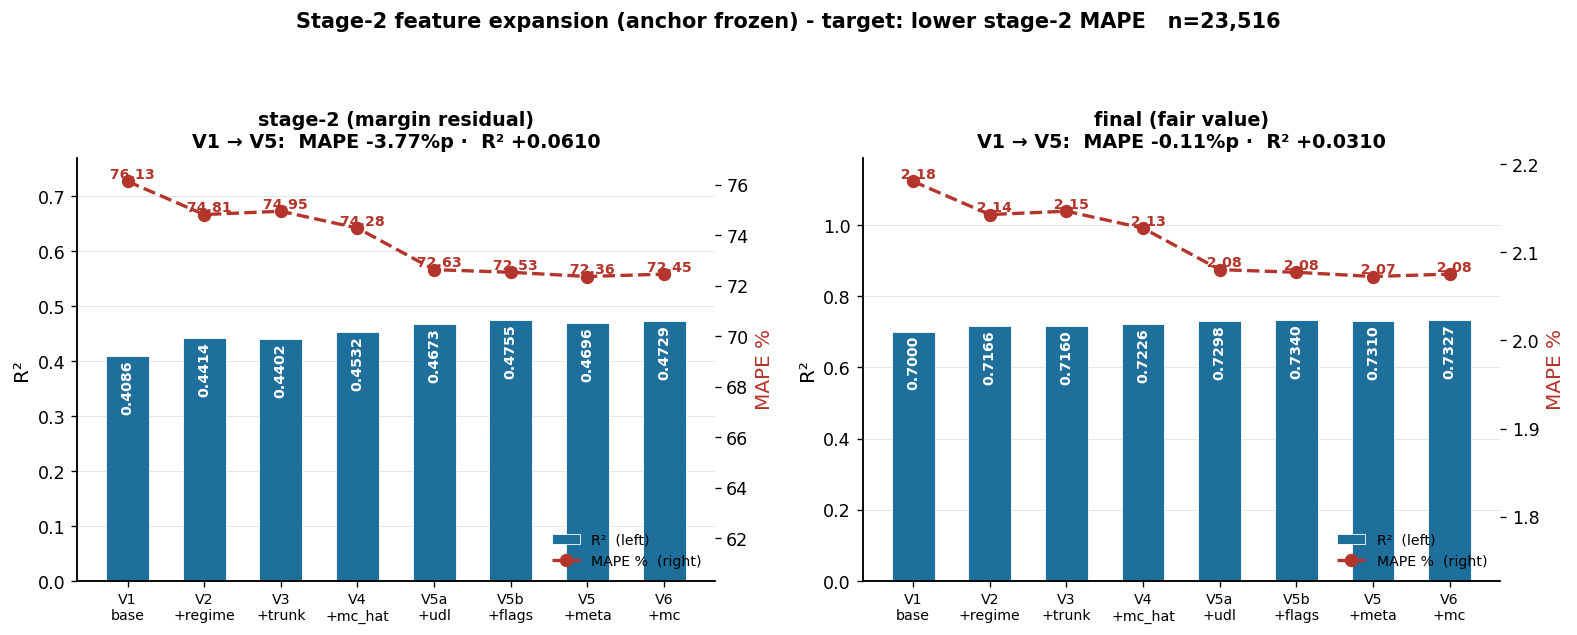


===== ALL (Δ = V1 대비) =====
            nfeat      n  stage2_R2  stage2_MAPE  final_R2  final_MAPE  s2MAPE_Δ   fR2_Δ  fMAPE_Δ
variant                                                                                          
V1 base        57  23516     0.4086      76.1281    0.7000      2.1805    0.0000  0.0000   0.0000
V2 +regime     63  23516     0.4414      74.8135    0.7166      2.1428   -1.3146  0.0166  -0.0377
V3 +trunk     131  23516     0.4402      74.9454    0.7160      2.1466   -1.1827  0.0160  -0.0339
V4 +mc_hat    132  23516     0.4532      74.2768    0.7226      2.1274   -1.8513  0.0226  -0.0530
V5a +udl      135  23516     0.4673      72.6331    0.7298      2.0804   -3.4950  0.0298  -0.1001
V5b +flags    135  23516     0.4755      72.5272    0.7340      2.0773   -3.6009  0.0339  -0.1031
V5 +meta      138  23516     0.4696      72.3605    0.7310      2.0726   -3.7676  0.0310  -0.1079
V6 +mc        140  23516     0.4729      72.4546    0.7327      2.0752   -3.6735  0.0326 

In [20]:
# 그림 13: stage-2 특성확장 ablation — 앵커 고정, stage-2 만 교체 (약 1.5분)
FORCE_S2 = False
_sp = fm.stat("ablation_stage2_features")
_want = {"V1 base", "V2 +regime", "V3 +trunk", "V4 +mc_hat", "V5a +udl", "V5b +flags",
         "V5 +meta", "V6 +mc"}
_stale2 = (not _sp.exists()) or set(pd.read_csv(_sp).variant) != _want

if FORCE_S2 or _stale2:
    import time, xgboost as _xgb
    from module import data as _DA
    from module.data import featnum as _featnum, CAT as _CAT, CONTRACT as _CONTRACT, time_weights
    from module.train import load_curve_predictor
    from module.pipeline import hybrid_residual_target

    _idx = D.ml.index

    def _blk(arr, names):
        return pd.DataFrame(np.asarray(arr), columns=names, index=_idx)

    _TRUNK = pd.concat([
        _blk(D.CURVE, [f"b_u{j}" for j in range(D.CURVE.shape[1])]),
        _blk(D.VC, ["b_sig1", "b_sig2", "b_sig3", "b_rho12", "b_rho13", "b_rho23", "b_sig_eff"]),
        _blk(D.CON, [f"t_{c}" for c in _CONTRACT])], axis=1)
    _BASE = D.ml[_featnum("base") + _CAT]
    _REG = D.ml[_featnum("regime") + _CAT]
    _raw = pd.read_parquet(fm.source())
    _lzb = [f"lz_barr_{j}" for j in range(12)]
    _META = pd.DataFrame({
        "m_udl1": _raw.udl1.astype("category").values, "m_udl2": _raw.udl2.astype("category").values,
        "m_udl3": _raw.udl3.astype("category").values,
        "m_pmt_linear": _raw.pmt_linear.astype("float32").values,
        "m_n_lz": _raw[_lzb].notna().sum(axis=1).astype("float32").values,
        "m_mc_r_krw": _raw.mc_r_krw.astype("float32").values}, index=_idx)
    _MC3 = ["m_udl1", "m_udl2", "m_udl3"]

    VAR = [("V1 base", lambda mh: _BASE),
           ("V2 +regime", lambda mh: _REG),
           ("V3 +trunk", lambda mh: pd.concat([_REG, _TRUNK], axis=1)),
           ("V4 +mc_hat", lambda mh: pd.concat([_REG, _TRUNK, _blk(mh, ["mc_hat"])], axis=1)),
           ("V5a +udl", lambda mh: pd.concat([_REG, _TRUNK, _blk(mh, ["mc_hat"]), _META[_MC3]], axis=1)),
           ("V5b +flags", lambda mh: pd.concat([_REG, _TRUNK, _blk(mh, ["mc_hat"]),
                                                _META.drop(columns=_MC3)], axis=1)),
           ("V5 +meta", lambda mh: pd.concat([_REG, _TRUNK, _blk(mh, ["mc_hat"]), _META], axis=1)),
           ("V6 +mc", lambda mh: pd.concat([_REG, _TRUNK, _blk(mh, ["mc_hat"]), _META,
                                            _blk(D.MC, ["mc"]), _blk(D.MC - mh, ["anchor_err"])], axis=1))]
    _P = cfg["tabular"]["xgb"]; _ES = cfg["train"].get("es_rounds", 50)
    _acc = {nm: [] for nm, _ in VAR}; _nf = {}
    _t0 = time.time()
    for k, (tr, va, te) in enumerate(D.WF):
        anc = load_curve_predictor(D, str(fm.RESULT / "models" / f"{STAGE_MODEL}_anchor_fold{k}.pt"))
        sel = np.concatenate([tr, va, te])
        mh = np.full(D.n, np.nan, dtype="float32"); mh[sel] = np.asarray(anc(sel), dtype="float32")
        rt = np.full(D.n, np.nan, dtype="float32")
        rt[sel] = hybrid_residual_target(D.FAIR[sel], mh[sel], D.rm[sel])
        for nm, build in VAR:
            X = build(mh)
            assert not X.columns.duplicated().any(), nm
            _nf[nm] = X.shape[1]
            m = _xgb.XGBRegressor(tree_method="hist", enable_categorical=True, random_state=0,
                                  early_stopping_rounds=_ES, **_P)
            m.fit(X.iloc[tr], rt[tr], sample_weight=time_weights(D, tr),
                  eval_set=[(X.iloc[va], rt[va])], verbose=False)
            rp = m.predict(X.iloc[te])
            _acc[nm].append(pd.DataFrame({
                "ITEM_CD": D.ITEM[te], "resid_true": rt[te], "resid_pred": rp,
                "y_true": D.FAIR[te], "y_pred": mh[te] + D.rm[te] + rp}))
    print(f"학습 완료 {time.time()-_t0:.0f}s")

    _sm = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn"]]
    _sm["ITEM_CD"] = _sm.pop("item").astype(str)
    _sm["struct"] = _sm.opt_type + " x " + np.where(_sm.ki_yn == 1, "KI", "no-KI")
    _sm = _sm.set_index("ITEM_CD")
    _SEG = [("STEP (all)", lambda z: z.opt_type == "STEP"),
            ("LIZARD (all)", lambda z: z.opt_type == "LIZARD"),
            ("ALL", lambda z: z.index == z.index)]
    _out = []
    for nm, _ in VAR:
        q = pd.concat(_acc[nm], ignore_index=True)
        q["ITEM_CD"] = q["ITEM_CD"].astype(str)
        q = q.join(_sm, on="ITEM_CD")
        for sn, f in _SEG:
            z = q[f(q)]
            e2 = np.abs((z.resid_pred - z.resid_true).values)
            ef = np.abs((z.y_pred - z.y_true).values)
            _out.append(dict(variant=nm, nfeat=_nf[nm], seg=sn, n=len(z),
                             stage2_R2=r2_score(z.resid_true, z.resid_pred),
                             stage2_MAPE=float(e2.mean() / z.resid_true.abs().mean() * 100),
                             stage2_RMSE=float(np.sqrt((e2 ** 2).mean()) * FACE),
                             final_R2=r2_score(z.y_true, z.y_pred),
                             final_MAPE=float(ef.mean() / z.y_true.abs().mean() * 100)))
    pd.DataFrame(_out).to_csv(_sp, index=False)

S2 = pd.read_csv(_sp)
ORD = ["V1 base", "V2 +regime", "V3 +trunk", "V4 +mc_hat", "V5a +udl", "V5b +flags",
       "V5 +meta", "V6 +mc"]
ORD = [v for v in ORD if v in set(S2.variant)]
Z = S2[S2.seg == "ALL"].set_index("variant").reindex(ORD)

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.4))
x = np.arange(len(ORD))
for a, pre, ttl in ((ax[0], "stage2", "stage-2 (margin residual)"),
                    (ax[1], "final", "final (fair value)")):
    b = a.bar(x, Z[f"{pre}_R2"], 0.56, color="#1f6f9c", edgecolor="white", linewidth=0.5,
              label="R²  (left)")
    for r, v in zip(b, Z[f"{pre}_R2"]):
        a.text(r.get_x() + r.get_width() / 2, v * 0.985, f"{v:.4f}", ha="center", va="top",
               fontsize=8.5, rotation=90, color="white", fontweight="bold")
    a.set_ylabel("R²"); a.set_ylim(0, Z[f"{pre}_R2"].max() * 1.62)
    a2 = a.twinx()
    a2.plot(x, Z[f"{pre}_MAPE"], "o--", color="#b3352b", lw=2.0, ms=7, label="MAPE %  (right)")
    for i, v in enumerate(Z[f"{pre}_MAPE"]):
        a2.text(x[i], v, f"  {v:.2f}", fontsize=8.5, color="#b3352b", fontweight="bold",
                va="bottom", ha="center")
    _lo, _hi = Z[f"{pre}_MAPE"].min(), Z[f"{pre}_MAPE"].max()
    a2.set_ylim(_lo - (_hi - _lo) * 3.2, _hi + (_hi - _lo) * 0.25)
    # MAPE 선을 막대 위쪽 띠에만 두어 R² 라벨과 겹치지 않게 한다
    a2.set_ylabel("MAPE %", color="#b3352b"); a2.grid(False)
    d2 = Z[f"{pre}_MAPE"].iloc[-2] - Z[f"{pre}_MAPE"].iloc[0]
    dr = Z[f"{pre}_R2"].iloc[-2] - Z[f"{pre}_R2"].iloc[0]
    a.set_title(f"{ttl}\nV1 → V5:  MAPE {d2:+.2f}%p ·  R² {dr:+.4f}", fontsize=11.5)
    a.set_xticks(x); a.set_xticklabels([v.replace(" ", "\n", 1) for v in ORD], fontsize=8.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
    a.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="lower right", framealpha=0.95)

fig.suptitle("Stage-2 feature expansion (anchor frozen) - target: lower stage-2 MAPE"
             f"   n={int(Z['n'].iloc[0]):,}", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("ablation_stage2_features"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

for sn in ("ALL", "STEP (all)"):
    _TT = S2[S2.seg == sn].set_index("variant").reindex(ORD)
    _TT = _TT[["nfeat", "n", "stage2_R2", "stage2_MAPE", "final_R2", "final_MAPE"]].copy()
    _TT["s2MAPE_Δ"] = _TT.stage2_MAPE - _TT.stage2_MAPE.iloc[0]
    _TT["fR2_Δ"] = _TT.final_R2 - _TT.final_R2.iloc[0]
    _TT["fMAPE_Δ"] = _TT.final_MAPE - _TT.final_MAPE.iloc[0]
    print(f"\n===== {sn} (Δ = V1 대비) =====")
    print(_TT.round(4).to_string())
print("\nsaved ->", fm.image("ablation_stage2_features").name, "|", _sp.name)

## 5-9. 요약


In [21]:
# 요약 표 (구조 × 모델 R²) + 저장물 목록
piv = S.pivot(index="struct", columns="model", values="R2").reindex(STRUCTS).round(4)
print("=== 구조별 R² ===")
print(piv.to_string())
print("\n=== 기초자산 지수별 R² (대표 모델) ===")
print(T[["ticker", "n", "R2", "MAPE", "BiasKRW"]].round(4).to_string(index=False))
print("\nsaved images ->", [p.name for p in sorted(fm.IMAGE.glob("seg_*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("seg_*.csv"))])

=== 구조별 R² ===
model           bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  deeponet_hybrid_pi_lizard  xgb_hybrid
struct                                                                                                                         
STEP x KI              0.1772           0.7835              0.7790                0.7823                     0.7813      0.7707
STEP x no-KI           0.4613           0.8189              0.8199                0.8235                     0.8224      0.8113
LIZARD x KI            0.2693           0.8367              0.8374                0.8351                     0.8388      0.8587
LIZARD x no-KI         0.2395           0.7732              0.7683                0.7733                     0.7779      0.7513

=== 기초자산 지수별 R² (대표 모델) ===
   ticker      n      R2   MAPE   BiasKRW
^STOXX50E 101825  0.8006 1.7431   -8.9154
    ^GSPC 101410  0.8168 1.7220   -1.4932
   ^KS200  57775  0.7172 1.7358  -29.5754
    ^N225  43425  0.